# Inférence statistique

> Modèles retenus : CatBoost, XGBoost, LightGBM (cible `log1p`) + Stacking OOF  
> Optimisation sur **MAPE** (au lieu de MAE) + feature engineering ciblé sur les petites valeurs.

## Imports & configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Manipulation de données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import json


# Modèles
from sklearn.linear_model import LinearRegression

# Évaluation et validation
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

from sklearn.inspection import permutation_importance

# Modèles de Gradient Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimisation d'hyperparamètres
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


import shap
from sklearn.base import BaseEstimator, RegressorMixin

from sklearn.impute import SimpleImputer
import lime
import lime.lime_tabular

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

RANDOM_STATE = 1308

### A.2 : Chargement des données

Split **temporel** : train 2020-2022 / val 2023 / test 2024. On entraîne toujours sur le passé et on évalue sur le futur.

In [2]:
# Chargement des données

df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")
df_en_cours = pd.read_csv("../data_finale/featuring/en_cours_featured.csv")

# On supprime les lignes avec des valeurs manquantes pour notre variable cible

colonne_cible  = "market_value_in_eur"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])
df_en_cours = df_en_cours.dropna(subset=[colonne_cible])

In [3]:
# Colonnes à supprimer pour l'entraînement

colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

cols_a_supprimer = [colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position"]

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val = df_val.drop(columns=cols_a_supprimer)
y_val = df_val[colonne_cible]

X_test = df_test.drop(columns=cols_a_supprimer)
y_test = df_test[colonne_cible]

X_en_cours = df_en_cours.drop(columns=cols_a_supprimer)
y_en_cours = df_en_cours[colonne_cible]

In [4]:
# Préparation pour certains modèles : sélection dynamique des colonnes sans aucun NaN
colonnes_sans_nan = X_train.columns[X_train.isna().sum() == 0].tolist()

print(f"Filtrage pour les modèles linéaires/SVR :")
print(f"{len(colonnes_sans_nan)} colonnes conservées sur {X_train.shape[1]}.")

X_train_sans_nan = X_train[colonnes_sans_nan]
X_val_sans_nan   = X_val[colonnes_sans_nan]
X_test_sans_nan  = X_test[colonnes_sans_nan]
X_en_cours_sans_nan = X_en_cours[colonnes_sans_nan]

Filtrage pour les modèles linéaires/SVR :
145 colonnes conservées sur 154.


### A.4 : Préparation des jeux de données X / y

In [5]:
cols_a_supprimer = [
    colonne_cible, colonne_joueur, colonne_team, colonne_nation,
    "position"
]

# On supprime uniquement les colonnes qui existent réellement

# On supprime (ou non) les colonnes normalisées
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]

df_train = df_train.drop(columns=colonnes_nor, errors="ignore")
df_val   = df_val.drop(columns=colonnes_nor, errors="ignore")
df_test  = df_test.drop(columns=colonnes_nor, errors="ignore")
df_en_cours = df_en_cours.drop(columns=colonnes_nor, errors="ignore")

# Construction des datasets d'entraînement, validation et test
X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]

X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

X_en_cours  = df_en_cours.drop(columns=cols_a_supprimer)
y_en_cours  = df_en_cours[colonne_cible]

# Cibles log
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)
y_en_cours_log  = np.log1p(y_en_cours)

# Poids d'entraînement : sur-pondère les petites valeurs pour améliorer le MAPE
sample_weights_train = 1 / np.log1p(y_train)
sample_weights_train = sample_weights_train / sample_weights_train.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")

X_train : (7404, 146) | X_val : (2431, 146) | X_test : (1751, 146)


### B2 : Comparaison des algorithmes (cible log)

**Ce qu'on teste :** quel algorithme, tuné avec Optuna, donne les meilleures performances ?

**Modèles comparés :** Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR et ElasticNet.

**Objectif Optuna :** RMSE log. On entraîne sur `log1p(y)` et on retransforme avec `expm1` pour les métriques.

**Ce qui varie ici :** l'algorithme.  
**Ce qui reste fixe :** pipeline Bloc A, objectif RMSE log, `N_TRIALS = 75`, `sample_weight = 1/log1p(y)`.


#### B2.7 — Construction des modèles finaux

In [6]:
with open("../modelisation/meilleurs_hyperparametres.json", "r") as f:
    params = json.load(f)

xgb_final = XGBRegressor(
    **params["XGBoost"],
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
lgbm_final = LGBMRegressor(
    **params["LightGBM"],
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cat_final = CatBoostRegressor(
    **params["CatBoost"],
    bootstrap_type="Bernoulli",
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0
)

modeles_finaux = {
    "XGBoost (log)":   xgb_final,
    "LightGBM (log)":  lgbm_final,
    "CatBoost (log)":  cat_final,
}


def evaluer_log(nom, modele, X_tr, y_tr_log, X_ev, y_ev, w=None):
    fit_kwargs = {"sample_weight": w} if w is not None else {}
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_tr, y_tr_log, eval_set=(X_ev, np.log1p(y_ev)), verbose=False, **fit_kwargs)
    else:
        modele.fit(X_tr, y_tr_log, **fit_kwargs)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"  {nom:12s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f} | R²adj : {r2_adj:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

print("Évaluation validation")
resultats_val = {}
for nom, modele in modeles_finaux.items():
    resultats_val[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_val, y_val, w=sample_weights_train)

df_val_res = pd.DataFrame(resultats_val).T.sort_values("MAPE")
print("\nClassement validation (MAPE croissant) :")
print(df_val_res)

Évaluation validation
  XGBoost (log) | MAPE : 41.92% | MAE :    3,016,439 € | R² : 0.8952 | R²adj : 0.8885
  LightGBM (log) | MAPE : 43.00% | MAE :    3,159,813 € | R² : 0.8826 | R²adj : 0.8751
  CatBoost (log) | MAPE : 42.98% | MAE :    3,222,441 € | R² : 0.8765 | R²adj : 0.8686

Classement validation (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)   3.016439e+06  5.825417e+06  0.419205  0.895225   0.888528
CatBoost (log)  3.222441e+06  6.323830e+06  0.429835  0.876530   0.868637
LightGBM (log)  3.159813e+06  6.167404e+06  0.430031  0.882562   0.875055


In [7]:
print("Évaluation test")
resultats_test = {}
for nom, modele in modeles_finaux.items():
    resultats_test[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_test, y_test, w=sample_weights_train)

df_test_res = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement test (MAPE croissant) :")
print(df_test_res)

Évaluation test
  XGBoost (log) | MAPE : 39.75% | MAE :    3,230,861 € | R² : 0.8832 | R²adj : 0.8725
  LightGBM (log) | MAPE : 40.21% | MAE :    3,345,161 € | R² : 0.8784 | R²adj : 0.8673
  CatBoost (log) | MAPE : 40.56% | MAE :    3,501,365 € | R² : 0.8671 | R²adj : 0.8550

Classement test (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)   3.230861e+06  6.244866e+06  0.397547  0.883164   0.872529
LightGBM (log)  3.345161e+06  6.372103e+06  0.402071  0.878354   0.867282
CatBoost (log)  3.501365e+06  6.660732e+06  0.405648  0.867085   0.854987


In [8]:
print("Évaluation année en cours")
resultats_en_cours = {}
for nom, modele in modeles_finaux.items():
    resultats_en_cours[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_en_cours, y_en_cours, w=sample_weights_train)

df_en_cours_res = pd.DataFrame(resultats_en_cours).T.sort_values("MAPE")
print("\nClassement en cours (MAPE croissant) :")
print(df_en_cours_res)

Évaluation année en cours
  XGBoost (log) | MAPE : 39.73% | MAE :    4,642,802 € | R² : 0.8048 | R²adj : 0.7821
  LightGBM (log) | MAPE : 40.31% | MAE :    4,683,891 € | R² : 0.8036 | R²adj : 0.7808
  CatBoost (log) | MAPE : 41.46% | MAE :    5,189,454 € | R² : 0.7551 | R²adj : 0.7267

Classement en cours (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost (log)   4.642802e+06  8.815345e+06  0.397342  0.804791   0.782117
LightGBM (log)  4.683891e+06  8.842618e+06  0.403143  0.803581   0.780767
CatBoost (log)  5.189454e+06  9.873500e+06  0.414593  0.755114   0.726671


### B3 : Stacking OOF (XGBoost + LightGBM + CatBoost)

Le Stacking OOF combine les 3 meilleurs modèles boosting via un méta-modèle linéaire à coefficients positifs (combinaison convexe).

Les prédictions OOF garantissent que chaque exemple du train reçoit une prédiction issue d'un modèle qui ne l'a jamais vu, contrairement à un split fixe qui biaiserait les poids du méta-modèle.

#### B3.1 — Génération des prédictions OOF et construction du méta-modèle

In [9]:
base_models = ["XGBoost (log)", "LightGBM (log)", "CatBoost (log)"]

# Charger le JSON
with open("../modelisation/poids_stacking.json", "r") as f:
    meta_config = json.load(f)


meta = LinearRegression(positive=True)
# On réinjecte les poids
meta.coef_ = np.array([meta_config["weights"][nom] for nom in base_models])
meta.intercept_ = float(meta_config["intercept"])

print("Méta-modèle reconstruit avec succès !")
print("Poids :", dict(zip(base_models, meta.coef_.round(3))))
print(f"Intercept : {meta.intercept_:,.2f} €")

# Entraîner les modèles de base
print("\nEntraînement des modèles de base...")
for nom in base_models:
    modele = modeles_finaux[nom]
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_train, y_train_log, eval_set=(X_val, y_val_log),
                   sample_weight=sample_weights_train, verbose=False)
    else:
        modele.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    print(f"  {nom} : entraîné")

# Prédictions sur Val et Test (repassées en Euros)
preds_val_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_val)) for nom in base_models}
preds_test_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_test)) for nom in base_models}
preds_en_cours_euros = {nom: np.expm1(modeles_finaux[nom].predict(X_en_cours)) for nom in base_models}

X_meta_val = pd.DataFrame(preds_val_euros)
X_meta_test = pd.DataFrame(preds_test_euros)
X_meta_en_cours = pd.DataFrame(preds_en_cours_euros)


pred_val_stack = meta.predict(X_meta_val)
pred_test_stack = meta.predict(X_meta_test)
pred_en_cours_stack = meta.predict(X_meta_en_cours)

preds_val_log  = {nom: modeles_finaux[nom].predict(X_val)  for nom in base_models}
preds_test_log = {nom: modeles_finaux[nom].predict(X_test) for nom in base_models}
preds_en_cours_log = {nom: modeles_finaux[nom].predict(X_en_cours) for nom in base_models}

print("\nPrédictions du Stacking calculées avec succès.")

Méta-modèle reconstruit avec succès !
Poids : {'XGBoost (log)': np.float64(0.77), 'LightGBM (log)': np.float64(0.102), 'CatBoost (log)': np.float64(0.184)}
Intercept : 422,249.15 €

Entraînement des modèles de base...
  XGBoost (log) : entraîné
  LightGBM (log) : entraîné
  CatBoost (log) : entraîné

Prédictions du Stacking calculées avec succès.


#### B3.2 — Comparaison Blend (moyenne) vs Stacking OOF

On compare deux stratégies d'assemblage :
- **Blend (moyenne simple)** : moyenne arithmétique des 3 prédictions : rapide mais sous-optimal
- **Stacking OOF** : méta-modèle linéaire à coefficients positifs : apprend les poids optimaux

In [10]:
# Blend 1 : moyenne simple
pred_val_moyenne  = X_meta_val.mean(axis=1)
pred_test_moyenne = X_meta_test.mean(axis=1)
pred_en_cours_moyenne = X_meta_en_cours.mean(axis=1)

print("Blend (moyenne simple)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_moyenne):,.0f} € | R² : {r2_score(y_val, pred_val_moyenne):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_moyenne):,.0f} € | R² : {r2_score(y_test, pred_test_moyenne):.4f}")
print(f"  En cours -> MAE : {mean_absolute_error(y_en_cours, pred_en_cours_moyenne):,.0f} € | R² : {r2_score(y_en_cours, pred_en_cours_moyenne):.4f}")


# Moyenne simple (baseline de comparaison)
pred_val_moy  = X_meta_val.mean(axis=1)
pred_test_moy = X_meta_test.mean(axis=1)
pred_en_cours_moy = X_meta_en_cours.mean(axis=1)

print("\n=== Comparaison finale (Validation) ===")
for label, preds in [("Stacking OOF", pred_val_stack), ("Moyenne simple", pred_val_moy)]:
    print(f"  {label:15s} | MAPE : {mean_absolute_percentage_error(y_val, preds):.2%} | MAE : {mean_absolute_error(y_val, preds):>12,.0f} € | R² : {r2_score(y_val, preds):.4f}")

Blend (moyenne simple)
  Val  -> MAE : 3,042,602 € | R² : 0.8910
  Test -> MAE : 3,273,178 € | R² : 0.8825
  En cours -> MAE : 4,713,058 € | R² : 0.7993

=== Comparaison finale (Validation) ===
  Stacking OOF    | MAPE : 55.32% | MAE :    3,034,585 € | R² : 0.8981
  Moyenne simple  | MAPE : 42.05% | MAE :    3,042,602 € | R² : 0.8910


In [11]:
comparaison_blend = pd.DataFrame({
    "MAE Val": {
        "CatBoost (log) seul": mean_absolute_error(y_val,  np.expm1(modeles_finaux["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     mean_absolute_error(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_val,  pred_val_stack),
    },
    "R2 Val": {
        "CatBoost (log) seul": r2_score(y_val,  np.expm1(modeles_finaux["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     r2_score(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":r2_score(y_val,  pred_val_stack),
    },
    "MAE Test": {
        "CatBoost (log) seul": mean_absolute_error(y_test, np.expm1(modeles_finaux["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     mean_absolute_error(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_test, pred_test_stack),
    },
    "R2 Test": {
        "CatBoost (log) seul": r2_score(y_test, np.expm1(modeles_finaux["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     r2_score(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":r2_score(y_test, pred_test_stack),
    },
}).sort_values("MAE Test")

print(comparaison_blend)

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (moyenne)       3.042602e+06  0.891041  3.273178e+06  0.882507
Blend (stacking OOF)  3.034585e+06  0.898132  3.289757e+06  0.890245
CatBoost (log) seul   3.222441e+06  0.876530  3.497073e+06  0.867574


#### B3.3 — Analyse d'erreur par tranche de valeur

On décompose l'erreur du meilleur modèle par tranche de valeur marchande pour identifier où le modèle peine le plus.

In [12]:
meilleure_prediction_test = pred_test_stack

tranches       = [0, 1_000_000, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches= ["<1M€", "1-5M€", "5-20M€", "20-50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese_tranches = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moyenne=("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese_tranches["% du total joueurs"]          = synthese_tranches["n_joueurs"] / len(df_erreur) * 100
synthese_tranches["% de l'erreur absolue totale"]= (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum() / df_erreur["erreur_abs"].sum() * 100
)


print(synthese_tranches)

         n_joueurs  valeur_moyenne           MAE      MAPE  \
tranche                                                      
<1M€           199    6.734925e+05  8.615146e+05  2.158270   
1-5M€          618    2.973463e+06  1.100551e+06  0.399904   
5-20M€         586    1.178584e+07  3.514234e+06  0.309035   
20-50M€        285    3.222105e+07  6.445882e+06  0.205368   
>50M€           63    8.190476e+07  1.606929e+07  0.191547   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<1M€              11.364934                      2.976225  
1-5M€             35.294118                     11.807251  
5-20M€            33.466591                     35.750183  
20-50M€           16.276413                     31.891666  
>50M€              3.597944                     17.574675  


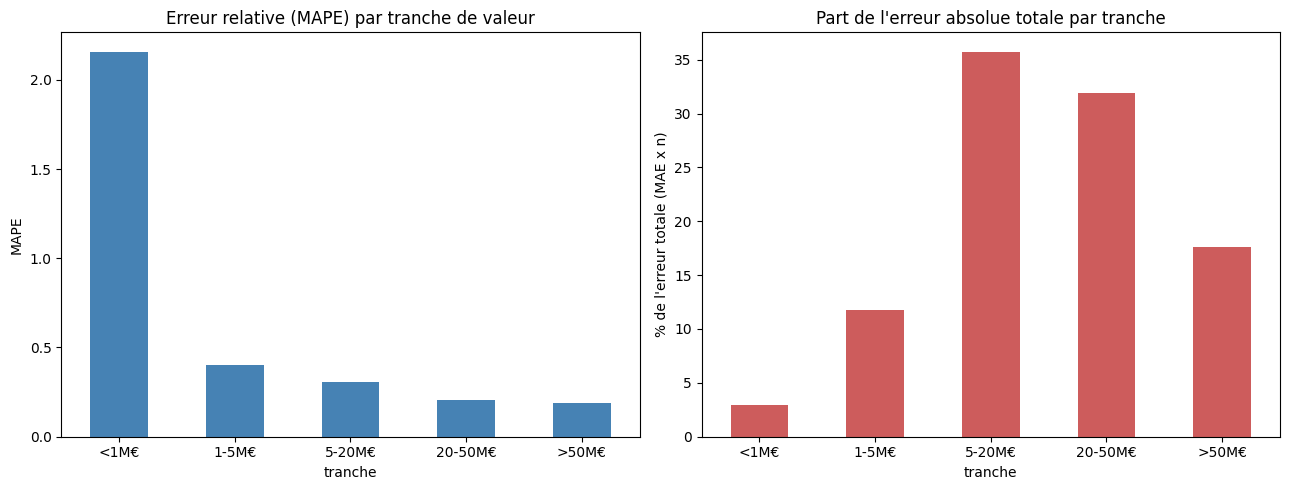

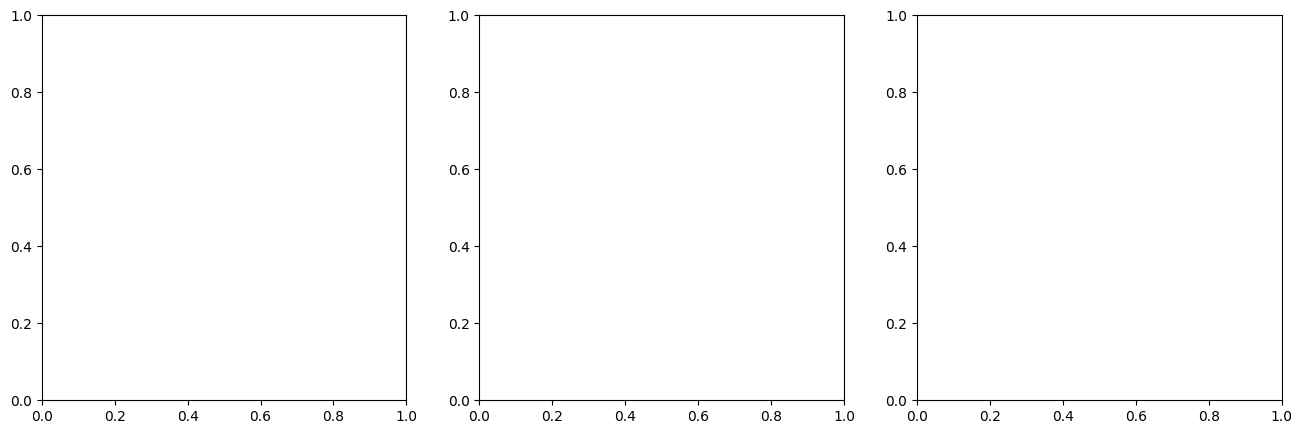

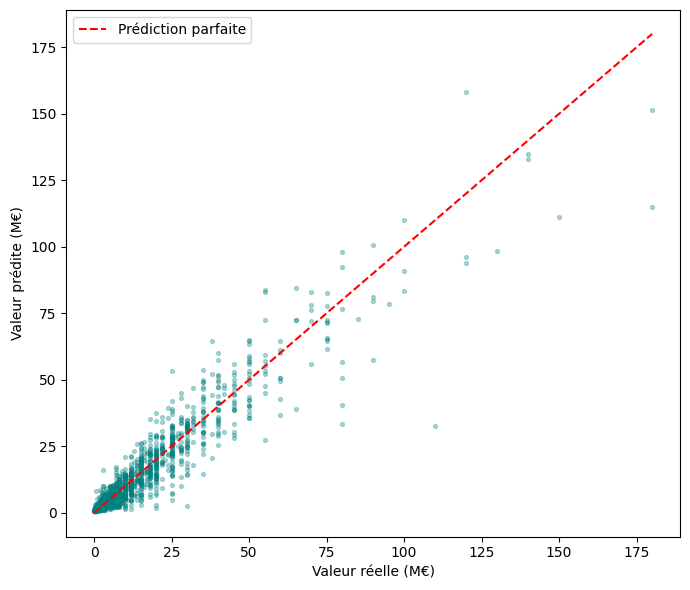

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

synthese_tranches["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Erreur relative (MAPE) par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)

synthese_tranches["% de l'erreur absolue totale"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale (MAE x n)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Valeurs réelles vs prédites
sample = df_erreur.sample(min(2000, len(df_erreur)), random_state=RANDOM_STATE)

plt.figure(figsize=(7, 6))

plt.scatter(
    sample["y_reel"] / 1e6,
    sample["y_pred"] / 1e6,
    alpha=0.3,
    s=8,
    color="teal",
)

lim = max(sample["y_reel"].max(), sample["y_pred"].max()) / 1e6
plt.plot([0, lim], [0, lim], "r--", lw=1.5, label="Prédiction parfaite")

plt.xlabel("Valeur réelle (M€)")
plt.ylabel("Valeur prédite (M€)")
plt.legend()

plt.tight_layout()
plt.show()

             n_joueurs  age_moyen  valeur_moyenne           MAE      MAPE  \
tranche_age                                                                 
<21 ans             67  17.656716    7.952985e+06  3.970717e+06  1.766235   
21-24 ans          672  21.869048    1.686689e+07  4.232865e+06  0.636454   
25-28 ans          533  26.448405    1.594878e+07  3.436239e+06  0.320263   
29-32 ans          355  30.332394    7.161127e+06  2.063218e+06  0.410953   
33+ ans            124  34.548387    2.506653e+06  6.926112e+05  0.529877   

             % du total joueurs  % de l'erreur absolue totale  
tranche_age                                                    
<21 ans                3.826385                      4.618423  
21-24 ans             38.378070                     49.380299  
25-28 ans             30.439749                     31.795123  
29-32 ans             20.274129                     12.715211  
33+ ans                7.081668                      1.490944  


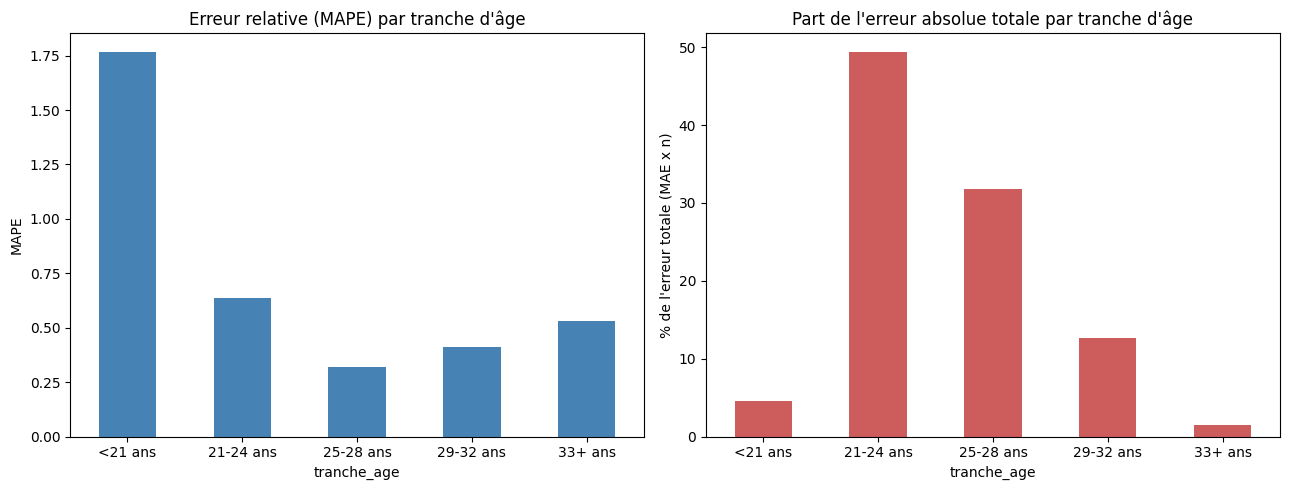

In [14]:
# Analyse d'erreur par tranche d'âge (même logique que par tranche de VM)

tranches_age = [0, 18, 24, 28, 32, 100]
labels_age   = ["<21 ans", "21-24 ans", "25-28 ans", "29-32 ans", "33+ ans"]

df_erreur_age = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
    "age": df_test["age"].values,
})
df_erreur_age["erreur_abs"] = (df_erreur_age["y_reel"] - df_erreur_age["y_pred"]).abs()
df_erreur_age["erreur_pct"] = df_erreur_age["erreur_abs"] / df_erreur_age["y_reel"]
df_erreur_age["tranche_age"] = pd.cut(df_erreur_age["age"], bins=tranches_age, labels=labels_age)

synthese_age = df_erreur_age.groupby("tranche_age", observed=True).agg(
    n_joueurs     =("y_reel",     "size"),
    age_moyen     =("age",        "mean"),
    valeur_moyenne=("y_reel",     "mean"),
    MAE           =("erreur_abs", "mean"),
    MAPE          =("erreur_pct", "mean"),
)
synthese_age["% du total joueurs"] = synthese_age["n_joueurs"] / len(df_erreur_age) * 100
synthese_age["% de l'erreur absolue totale"] = (
    df_erreur_age.groupby("tranche_age", observed=True)["erreur_abs"].sum()
    / df_erreur_age["erreur_abs"].sum() * 100
)

print(synthese_age)

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

synthese_age["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Erreur relative (MAPE) par tranche d'âge")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)

synthese_age["% de l'erreur absolue totale"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Part de l'erreur absolue totale par tranche d'âge")
axes[1].set_ylabel("% de l'erreur totale (MAE x n)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

            n_joueurs  valeur_moyenne           MAE      MAPE  \
position                                                        
Midfield          501    1.507151e+07  3.734119e+06  0.450234   
Defender          633    1.161224e+07  2.874426e+06  0.503133   
Goalkeeper        134    8.055224e+06  2.391323e+06  0.575467   
Attack            483    1.499037e+07  3.622406e+06  0.635954   

            % du total joueurs  % de l'erreur absolue totale  
position                                                      
Midfield             28.612222                     32.477001  
Defender             36.150771                     31.586746  
Goalkeeper            7.652770                      5.562794  
Attack               27.584238                     30.373459  


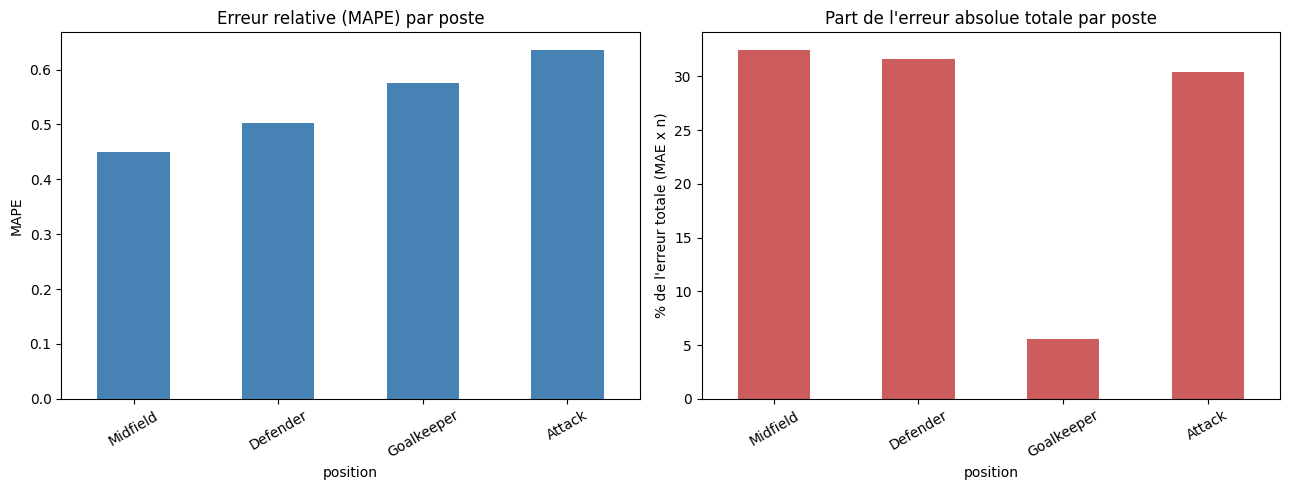

In [15]:
# Analyse d'erreur par poste (même logique que par tranche de VM)

N_MIN_OBS_POSTE = 20  # on ignore les postes trop peu représentés

df_erreur_poste = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
    "position": df_test["position"].values,
})
df_erreur_poste["erreur_abs"] = (df_erreur_poste["y_reel"] - df_erreur_poste["y_pred"]).abs()
df_erreur_poste["erreur_pct"] = df_erreur_poste["erreur_abs"] / df_erreur_poste["y_reel"]

# On retire les postes anecdotiques
effectifs = df_erreur_poste["position"].value_counts()
postes_retenus = effectifs[effectifs >= N_MIN_OBS_POSTE].index
df_erreur_poste = df_erreur_poste[df_erreur_poste["position"].isin(postes_retenus)]

synthese_poste = df_erreur_poste.groupby("position", observed=True).agg(
    n_joueurs     =("y_reel",     "size"),
    valeur_moyenne=("y_reel",     "mean"),
    MAE           =("erreur_abs", "mean"),
    MAPE          =("erreur_pct", "mean"),
).sort_values("MAPE")

synthese_poste["% du total joueurs"] = synthese_poste["n_joueurs"] / len(df_erreur_poste) * 100
synthese_poste["% de l'erreur absolue totale"] = (
    df_erreur_poste.groupby("position", observed=True)["erreur_abs"].sum()
    / df_erreur_poste["erreur_abs"].sum() * 100
)

print(synthese_poste)

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

synthese_poste["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Erreur relative (MAPE) par poste")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=30)

synthese_poste["% de l'erreur absolue totale"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Part de l'erreur absolue totale par poste")
axes[1].set_ylabel("% de l'erreur totale (MAE x n)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

#### B3.4 — Feature importance (CatBoost)

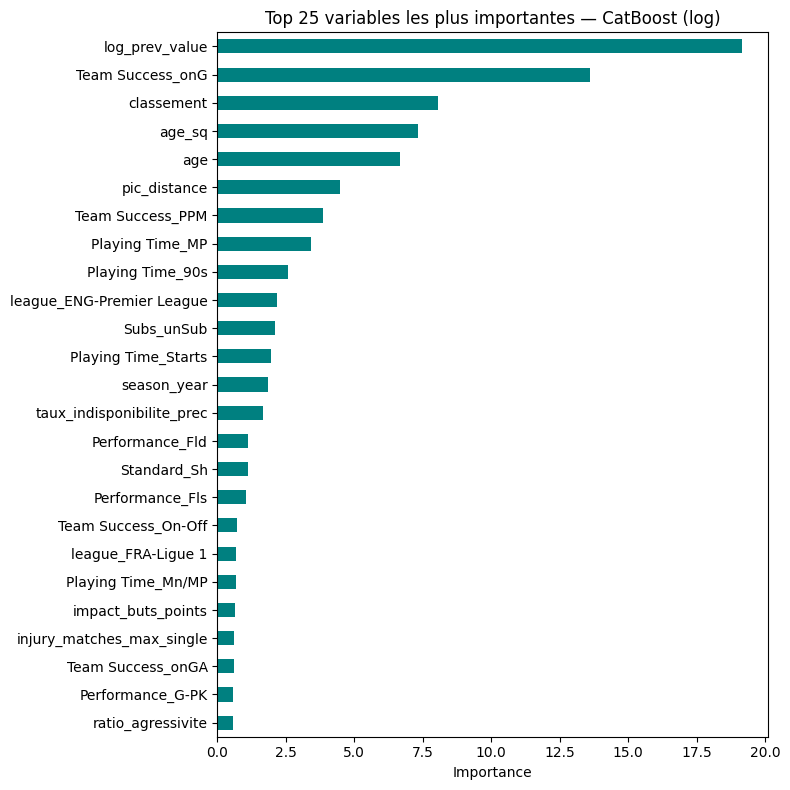

log_prev_value               19.154719
Team Success_onG             13.611816
classement                    8.065035
age_sq                        7.312114
age                           6.665142
pic_distance                  4.462647
Team Success_PPM              3.867401
Playing Time_MP               3.397784
Playing Time_90s              2.593138
league_ENG-Premier League     2.162216
Subs_unSub                    2.119057
Playing Time_Starts           1.941607
season_year                   1.830600
taux_indisponibilite_prec     1.660435
Performance_Fld               1.120705
Standard_Sh                   1.099941
Performance_Fls               1.057982
Team Success_On-Off           0.731205
league_FRA-Ligue 1            0.684777
Playing Time_Mn/MP            0.676319
impact_buts_points            0.625792
injury_matches_max_single     0.618370
Team Success_onGA             0.600648
Performance_G-PK              0.583892
ratio_agressivite             0.571963
dtype: float64


In [16]:
importances = pd.Series(
    modeles_finaux["CatBoost (log)"].get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(25).sort_values().plot(kind="barh", color="teal")
plt.title("Top 25 variables les plus importantes — CatBoost (log)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.head(25))

## Évaluation finale sur le TEST

> À lancer une seule fois, après avoir figé le choix du modèle sur la validation.

In [17]:
print("=== RÉSULTATS FINAUX (Test) ===")
resultats_test = {}
for label, preds in [
    ("Stacking OOF",  pred_test_stack),
    ("Moyenne simple",pred_test_moy),
    ("XGBoost seul",  np.expm1(preds_test_log["XGBoost (log)"])),
    ("LightGBM seul", np.expm1(preds_test_log["LightGBM (log)"])),
    ("CatBoost seul", np.expm1(preds_test_log["CatBoost (log)"])),
]:
    mae  = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    n, p = len(y_test), X_test.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_test[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_test_final = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_test_final)

# Modèle retenu
meilleure_prediction_test = pred_test_stack

=== RÉSULTATS FINAUX (Test) ===
  Stacking OOF    | MAPE : 53.02% | MAE :    3,289,757 € | R² : 0.8902
  Moyenne simple  | MAPE : 39.62% | MAE :    3,273,178 € | R² : 0.8825
  XGBoost seul    | MAPE : 39.75% | MAE :    3,230,861 € | R² : 0.8832
  LightGBM seul   | MAPE : 40.21% | MAE :    3,345,161 € | R² : 0.8784
  CatBoost seul   | MAPE : 40.54% | MAE :    3,497,073 € | R² : 0.8676

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
Moyenne simple  0.396218  3.273178e+06  0.882507   0.871813
XGBoost seul    0.397547  3.230861e+06  0.883164   0.872529
LightGBM seul   0.402071  3.345161e+06  0.878354   0.867282
CatBoost seul   0.405437  3.497073e+06  0.867574   0.855520
Stacking OOF    0.530170  3.289757e+06  0.890245   0.880255


In [18]:
print("=== RÉSULTATS FINAUX (Année en cours) ===")
resultats_en_cours = {}
for label, preds in [
    ("Stacking OOF",  pred_en_cours_stack),
    ("Moyenne simple",pred_en_cours_moy),
    ("XGBoost seul",  np.expm1(preds_en_cours_log["XGBoost (log)"])),
    ("LightGBM seul", np.expm1(preds_en_cours_log["LightGBM (log)"])),
    ("CatBoost seul", np.expm1(preds_en_cours_log["CatBoost (log)"])),
]:
    mae  = mean_absolute_error(y_en_cours, preds)
    mape = mean_absolute_percentage_error(y_en_cours, preds)
    r2   = r2_score(y_en_cours, preds)
    n, p = len(y_en_cours), X_en_cours.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_en_cours[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_en_cours_final = pd.DataFrame(resultats_en_cours).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_en_cours_final)

# Modèle retenu
meilleure_prediction_en_cours = pred_en_cours_stack

=== RÉSULTATS FINAUX (Année en cours) ===
  Stacking OOF    | MAPE : 43.74% | MAE :    4,385,101 € | R² : 0.8244
  Moyenne simple  | MAPE : 40.05% | MAE :    4,713,058 € | R² : 0.7993
  XGBoost seul    | MAPE : 39.73% | MAE :    4,642,802 € | R² : 0.8048
  LightGBM seul   | MAPE : 40.31% | MAE :    4,683,891 € | R² : 0.8036
  CatBoost seul   | MAPE : 41.55% | MAE :    5,057,015 € | R² : 0.7701

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
XGBoost seul    0.397342  4.642802e+06  0.804791   0.782117
Moyenne simple  0.400546  4.713058e+06  0.799325   0.776016
LightGBM seul   0.403143  4.683891e+06  0.803581   0.780767
CatBoost seul   0.415482  5.057015e+06  0.770130   0.743431
Stacking OOF    0.437371  4.385101e+06  0.824411   0.804016


In [19]:
class StackingModel(BaseEstimator, RegressorMixin):

    def __init__(self, models, meta_model):
        self.models = models
        self.meta_model = meta_model

    def fit(self, X, y):
        # Pas besoin de réentraîner les modèles,
        # ils sont déjà entraînés dans ton notebook
        return self

    def predict(self, X):
        # Prédictions des modèles de niveau 1, repassées en euros (comme en cellule 17)
        X_meta = np.column_stack([
            np.expm1(model.predict(X)) for model in self.models
        ])

        # Le méta-modèle prédit directement en euros, pas besoin d'expm1 ensuite
        prediction_euros = self.meta_model.predict(X_meta)

        return prediction_euros



modele_stack = StackingModel(
    models=[
        modeles_finaux["XGBoost (log)"],
        modeles_finaux["LightGBM (log)"],
        modeles_finaux["CatBoost (log)"]
    ],
    meta_model=meta
)


print("--- PERMUTATION FEATURE IMPORTANCE ---")


result_perm = permutation_importance(
    modele_stack,
    X_val,
    y_val,
    scoring="r2",
    n_repeats=1,
    random_state=1308,
    n_jobs=-1
)


# Organisation des résultats
sorted_idx = result_perm.importances_mean.argsort()[::-1]


perm_importances = pd.DataFrame(
    {
        "Feature": X_val.columns[sorted_idx],
        "Importance_Mean": result_perm.importances_mean[sorted_idx],
        "Importance_Std": result_perm.importances_std[sorted_idx]
    }
)


print(perm_importances)

--- PERMUTATION FEATURE IMPORTANCE ---
                       Feature  Importance_Mean  Importance_Std
0               log_prev_value         0.380297             0.0
1             Team Success_onG         0.117041             0.0
2                          age         0.094899             0.0
3                   classement         0.055375             0.0
4                 pic_distance         0.023460             0.0
..                         ...              ...             ...
141  injury_matches_max_single        -0.000457             0.0
142               Starts_Compl        -0.000474             0.0
143     injury_musculaire_nb_m        -0.001477             0.0
144                         xa        -0.001746             0.0
145                 xg_buildup        -0.004381             0.0

[146 rows x 3 columns]


In [20]:
DICT_VARIABLES = {
        # Famille : Identité, âge et physique
        "player": ("Nom du joueur", "Identité et physique"),
        "team": ("Club du joueur", "Identité et physique"),
        "nation": ("Nationalité", "Identité et physique"),
        "Age (age + age_sq)": ("Âge du joueur", "Identité et physique"),
        "pic_distance": ("Distance de l'âge du pic de valeur", "Identité et physique"),
        "pic_age": ("Âge du pic de valeur (0/1)", "Identité et physique"),
        "height_in_cm": ("Taille (en cm)", "Identité et physique"),
        "position": ("Poste général", "Identité et physique"),
        "foot_both": ("Ambidextre (0/1)", "Identité et physique"),
        "foot_left": ("Gaucher (0/1)", "Identité et physique"),
        "foot_right": ("Droitier (0/1)", "Identité et physique"),
        # Famille : Postes et sub-positions
        "pos_DF": ("Défenseur (0/1)", "Postes"),
        "pos_FW": ("Attaquant (0/1)", "Postes"),
        "pos_GK": ("Gardien de but (0/1)", "Postes"),
        "pos_MF": ("Milieu de terrain (0/1)", "Postes"),
        "sub_position_Attacking Midfield": (
            "Milieu offensif (0/1)",
            "Postes",
        ),
        "sub_position_Central Midfield": (
            "Milieu central (0/1)",
            "Postes",
        ),
        "sub_position_Centre-Back": (
            "Défenseur central (0/1)",
            "Postes",
        ),
        "sub_position_Centre-Forward": (
            "Avant-centre (0/1)",
            "Postes",
        ),
        "sub_position_Defensive Midfield": (
            "Milieu défensif (0/1)",
            "Postes",
        ),
        "sub_position_Goalkeeper": (
            "Gardien (Sous-poste 0/1)",
            "Postes",
        ),
        "sub_position_Left Midfield": (
            "Milieu gauche (0/1)",
            "Postes",
        ),
        "sub_position_Left Winger": (
            "Ailier gauche (0/1)",
            "Postes",
        ),
        "sub_position_Left-Back": (
            "Latéral gauche (0/1)",
            "Postes",
        ),
        "sub_position_Right Midfield": (
            "Milieu droit (0/1)",
            "Postes",
        ),
        "sub_position_Right Winger": (
            "Ailier droit (0/1)",
            "Postes",
        ),
        "sub_position_Right-Back": (
            "Latéral droit (0/1)",
            "Postes",
        ),
        "sub_position_Second Striker": (
            "Neuf et demi / Second attaquant (0/1)",
            "Postes",
        ),
        "est_polyvalent": (
            "Joueur polyvalent (0/1)",
            "Postes",
        ),
        # Famille : Championnats et contexte international
        "league_ENG-Premier League": (
            "Évolue en Premier League (0/1)",
            "Ligues et contexte international",
        ),
        "league_ESP-La Liga": (
            "Évolue en La Liga (0/1)",
            "Ligues et contexte international",
        ),
        "league_FRA-Ligue 1": (
            "Évolue en Ligue 1 (0/1)",
            "Ligues et contexte international",
        ),
        "league_GER-Bundesliga": (
            "Évolue en Bundesliga (0/1)",
            "Ligues et contexte international",
        ),
        "league_ITA-Serie A": (
            "Évolue en Serie A (0/1)",
            "Ligues et contexte international",
        ),
        "classement_FIFA_1": (
            "Sélection nationale Rang FIFA : 1",
            "Ligues et contexte international",
        ),
        "classement_FIFA_2": (
            "Sélection nationale Rang FIFA : 2",
            "Ligues et contexte international",
        ),
        "classement_FIFA_3": (
            "Sélection nationale Rang FIFA : 3",
            "Ligues et contexte international",
        ),
        "classement_FIFA_4": (
            "Sélection nationale Rang FIFA : 4",
            "Ligues et contexte international",
        ),
        "classement_FIFA_5": (
            "Sélection nationale Rang FIFA : 5",
            "Ligues et contexte international",
        ),
        "classement_FIFA_6": (
            "Sélection nationale Rang FIFA : 6",
            "Ligues et contexte international",
        ),
        "classement_FIFA_7": (
            "Sélection nationale Rang FIFA : 7",
            "Ligues et contexte international",
        ),
        "classement_FIFA_8": (
            "Sélection nationale Rang FIFA : 8",
            "Ligues et contexte international",
        ),
        "classement_FIFA_9": (
            "Sélection nationale Rang FIFA : 9",
            "Ligues et contexte international",
        ),
        "classement_FIFA_10": (
            "Sélection nationale Rang FIFA : 10",
            "Ligues et contexte international",
        ),
        "score_hype_nation": (
            "Score de hype de la sélection nationale",
            "Ligues et contexte international",
        ),
        # Famille : Temps de jeu, contrat et chronologie
        "season_year": ("Année de la saison", "Temps de jeu & Contrat"),
        "delta_minutes_jouees": (
            "Différence de minutes jouées par rapport à la saison précédente",
            "Temps de jeu et contrat",
        ),
        "contrat_jours_restants": (
            "Jours de contrat restants",
            "Temps de jeu et contrat",
        ),
        "Playing Time_MP": ("Matchs disputés", "Temps de jeu et contrat"),
        "Playing Time_Starts": (
            "Titularisations",
            "Temps de jeu et contrat",
        ),
        "Playing Time_90s": (
            "Nombre de 90 minutes complétées",
            "Temps de jeu et contrat",
        ),
        "Playing Time_Mn/MP": (
            "Minutes jouées par match disputé",
            "Temps de jeu et contrat",
        ),
        "Starts_Mn/Start": (
            "Minutes par titularisation",
            "Temps de jeu et contrat",
        ),
        "Starts_Compl": (
            "Matchs commencés et terminés en entier",
            "Temps de jeu et contrat",
        ),
        "Subs_Subs": (
            "Entrées en cours de match (Remplaçant)",
            "Temps de jeu et contrat",
        ),
        "Subs_Mn/Sub": ("Minutes par entrée en jeu", "Temps de jeu et contrat"),
        "Subs_unSub": (
            "Matchs passés sur le banc sans entrer",
            "Temps de jeu et contrat",
        ),
        "taux_matchs_termines": (
            "Taux de matchs terminés",
            "Temps de jeu et contrat",
        ),
        # Famille : Performance Offensive (Volume et efficacité)
        "Performance_Gls": ("Buts marqués", "Performance offensive"),
        "Performance_Ast": ("Passes décisives", "Performance offensive"),
        "Performance_G-PK": ("Buts hors pénaltys", "Performance offensive"),
        "Performance_PK": ("Pénaltys marqués", "Performance offensive"),
        "Performance_PKatt": ("Pénaltys tentés", "Performance offensive"),
        "Standard_Sh": ("Tirs totaux effectués", "Performance offensive"),
        "Standard_SoT": ("Tirs cadrés", "Performance offensive"),
        "Standard_SoT%": (
            "Pourcentage de tirs cadrés",
            "Performance offensive",
        ),
        "Standard_Sh/90": (
            "Tirs effectués par 90 min",
            "Performance offensive",
        ),
        "Standard_SoT/90": ("Tirs cadrés par 90 min", "Performance offensive"),
        "Standard_G/Sh": ("Buts par tir tenté", "Performance offensive"),
        "Standard_G/SoT": ("Buts par tir cadré", "Performance offensive"),
        "Performance_Off": ("Hors-jeux signalés", "Performance offensive"),
        "Performance_Crs": ("Centres vers la surface", "Performance offensive"),
        "Performance_PKwon": ("Pénaltys obtenus", "Performance offensive"),
        "Per 90 Minutes_Gls": ("Buts par 90 min", "Performance offensive"),
        "Per 90 Minutes_Ast": (
            "Passes décisives par 90 min",
            "Performance offensive",
        ),
        "Per 90 Minutes_G+A": (
            "Buts + Assists par 90 min",
            "Performance offensive",
        ),
        "Performance_Fld": ("Fautes subies", "Performance offensive"),
        "indice_danger_tirs": (
            "Indice de danger des tirs (xG par tir)", "Performance offensive"
        ),
        "efficacite_devant_but": (
            "Efficacité devant le but", "Performance offensive"
        ),
        "contribution_offensive_equipe": (
            "Contribution offensive à l'équipe (Buts + Assists / Total équipe)", "Performance offensive"
        ),
        "rentabilite_buts_minutes": (
            "Rentabilité des buts par minute jouée", "Performance offensive"
        ),
        "impact_buts_points": (
            "Impact des buts sur les points gagnés par l'équipe", "Performance offensive"
        ),
        "ratio_buts_hors_penalty": (
            "Ratio de buts hors pénaltys", "Performance offensive"
        ),
        "ratio_buts_penalty": (
            "Ratio de buts sur pénaltys", "Performance offensive"
        ),
        # Famille : Statistiques avancées (xG, xA, Création)
        "xg": ("Expected Goals (xG)", "Statistiques avancées"),
        "delta_xg": (
            "Différence de xG par rapport à la saison précédente", "Statistiques avancées"
        ),
        "xa": ("Expected Assists (xa)", "Statistiques avancées"),
        "xg_chain": (
            "Chaîne Expected Goals (xG Chain)",
            "Statistiques avancées",
        ),
        "xg_buildup": (
            "Construction Expected Goals",
            "Statistiques avancées",
        ),
        # Famille : Discipline et performance défensive
        "Performance_CrdY": ("Cartons jaunes reçus", "Discipline et défense"),
        "Performance_CrdR": ("Cartons rouges reçus", "Discipline et défense"),
        "ratio_agressivite": (
            "Ratio agressivité", "Discipline et défense"
        ),
        "Performance_2CrdY": (
            "Expulsions suite à 2 jaunes",
            "Discipline et défense",
        ),
        "Performance_Fls": ("Fautes commises", "Discipline et défense"),
        "Performance_Int": ("Interceptions de passes", "Discipline et défense"),
        "Performance_TklW": ("Tacles réussis", "Discipline et défense"),
        "Performance_PKcon": ("Pénaltys concédés", "Discipline et défense"),
        "Performance_OG": (
            "Buts contre son camp (OG)",
            "Discipline et défense",
        ),
        "indiscipline_par_90": (
            "Indiscipline par 90 min",
            "Discipline et défense"
        ),
        # Famille : Collectif et succès équipe
        "classement": ("Classement de l'équipe", "Succès équipe et collectif"),
        "Team Success_PPM": (
            "Points par match gagnés par l'équipe",
            "Succès équipe et collectif",
        ),
        "Team Success_onG": (
            "Buts marqués par l'équipe (si présent)",
            "Succès équipe et collectif",
        ),
        "Team Success_onGA": (
            "Buts encaissés par l'équipe (si présent)",
            "Succès équipe et collectif",
        ),
        "Team Success_On-Off": (
            "Impact On-Off de la présence du joueur",
            "Succès équipe et collectif",
        ),
        # Famille : Spécifique Gardien de but
        "Performance_GA": ("Buts encaissés", "Spécifique gardien"),
        "Performance_GA90": (
            "Buts encaissés par 90 min",
            "Spécifique gardien",
        ),
        "Performance_Saves": ("Arrêts effectués", "Spécifique gardien"),
        "Performance_Save%": ("Pourcentage d'arrêts", "Spécifique gardien"),
        "Performance_W": (
            "Victoires de l'équipe (si présent)",
            "Spécifique gardien",
        ),
        "Performance_D": (
            "Matchs nuls de l'équipe (si présent)",
            "Spécifique gardien",
        ),
        "Performance_L": (
            "Défaites de l'équipe (si présent)",
            "Spécifique gardien",
        ),
        "Performance_CS": (
            "Clean Sheets (Matchs sans but)",
            "Spécifique gardien",
        ),
        "Performance_CS%": (
            "Pourcentage de Clean Sheets",
            "Spécifique gardien",
        ),
        "Penalty Kicks_PKA": ("Pénaltys encaissés", "Spécifique gardien"),
        "Penalty Kicks_PKsv": ("Pénaltys arrêtés", "Spécifique gardien"),
        "Penalty Kicks_PKm": (
            "Pénaltys ratés par l'adversaire",
            "Spécifique gardien",
        ),
        "Penalty Kicks_Save%": (
            "Pourcentage de pénaltys arrêtés",
            "Spécifique gardien",
        ),
        "taux_arretXtaille_gardien": (
            "Taux d'arrêts par rapport à la taille du gardien", "Spécifique gardien"
        ),
        # Famille : Historique médical (Blessures)
        "injury_nb_total": ("Nombre total de blessures", "Historique médical"),
        "injury_days_total": (
            "Total des jours d'absence",
            "Historique médical",
        ),
        "injury_matches_max_single": (
            "Max de matchs manqués sur une blessure",
            "Historique médical",
        ),
        "injury_musculaire": (
            "Blessure musculaire (Présence 0/1)",
            "Historique médical",
        ),
        "injury_musculaire_nb_d": (
            "Jours d'absence - Muscle",
            "Historique médical",
        ),
        "injury_musculaire_nb_m": (
            "Matchs manqués - Muscle",
            "Historique médical",
        ),
        "injury_genou": (
            "Blessure au genou (Présence 0/1)",
            "Historique médical",
        ),
        "injury_genou_nb_d": ("Jours d'absence - Genou", "Historique médical"),
        "injury_genou_nb_m": ("Matchs manqués - Genou", "Historique médical"),
        "injury_cheville_pied": (
            "Blessure cheville/pied (Présence 0/1)",
            "Historique médical",
        ),
        "injury_cheville_pied_nb_d": (
            "Jours d'absence - Cheville/Pied",
            "Historique médical",
        ),
        "injury_cheville_pied_nb_m": (
            "Matchs manqués - Cheville/Pied",
            "Historique médical",
        ),
        "injury_mollet_tibia": (
            "Blessure mollet/tibia (Présence 0/1)",
            "Historique médical",
        ),
        "injury_mollet_tibia_nb_d": (
            "Jours d'absence - Mollet/Tibia",
            "Historique médical",
        ),
        "injury_mollet_tibia_nb_m": (
            "Matchs manqués - Mollet/Tibia",
            "Historique médical",
        ),
        "injury_dos_bassin": (
            "Blessure dos/bassin (Présence 0/1)",
            "Historique médical",
        ),
        "injury_dos_bassin_nb_d": (
            "Jours d'absence - Dos/Bassin",
            "Historique médical",
        ),
        "injury_dos_bassin_nb_m": (
            "Matchs manqués - Dos/Bassin",
            "Historique médical",
        ),
        "injury_trauma_severe": (
            "Traumatisme sévère/Opération (Présence 0/1)",
            "Historique médical",
        ),
        "injury_trauma_severe_nb_d": (
            "Jours d'absence - Traumatisme Sévère",
            "Historique médical",
        ),
        "injury_trauma_severe_nb_m": (
            "Matchs manqués - Traumatisme Sévère",
            "Historique médical",
        ),
        "injury_medical_repos": (
            "Maladie / Repos obligatoire (Présence 0/1)",
            "Historique médical",
        ),
        "injury_medical_repos_nb_d": (
            "Jours d'absence - Maladie/Repos",
            "Historique médical",
        ),
        "injury_medical_repos_nb_m": (
            "Matchs manqués - Maladie/Repos",
            "Historique médical",
        ),
        "injury_minor_unknown": (
            "Blessure mineure/inconnue (Présence 0/1)",
            "Historique médical",
        ),
        "injury_minor_unknown_nb_d": (
            "Jours d'absence - Blessure mineure",
            "Historique médical",
        ),
        "injury_minor_unknown_nb_m": (
            "Matchs manqués - Blessure mineure",
            "Historique médical",
        ),
        "taux_indisponibilite": (
            "Taux d'indisponibilité (Jours d'absence / 365)",
            "Historique médical",
        ),
        "fragilite_chronique": (
            "Fragilité chronique (0/1)",
            "Historique médical",
        ),
    }

DICT_VARIABLES["log_prev_value"] = (
       "Valeur marchande (log) - Saison précédente",
       "Temps de jeu et contrat",
   )

PALETTE_PRO = {
    "Identité et physique": "#2B3A4A",             # Bleu nuit / Ardoise
    "Postes": "#0066FF",                            # Bleu électrique vif
    "Ligues et contexte international": "#00A896",   # Teal / Vert d'eau foncé
    "Temps de jeu et contrat": "#00B4D8",            # Cyan / Bleu ciel vif
    "Performance offensive": "#FF5A5F",              # Coral / Rouge vif
    "Statistiques avancées": "#8E44AD",             # Violet profond
    "Discipline et défense": "#E67E22",             # Orange cuivré
    "Succès équipe et collectif": "#2ECC71",        # Vert émeraude
    "Spécifique gardien": "#F1C40F",                 # Jaune ambre
    "Historique médical": "#E056FD",               # Rose néon / Magenta
    "Non Classifié": "#95A5A6",                     # Gris neutre
}

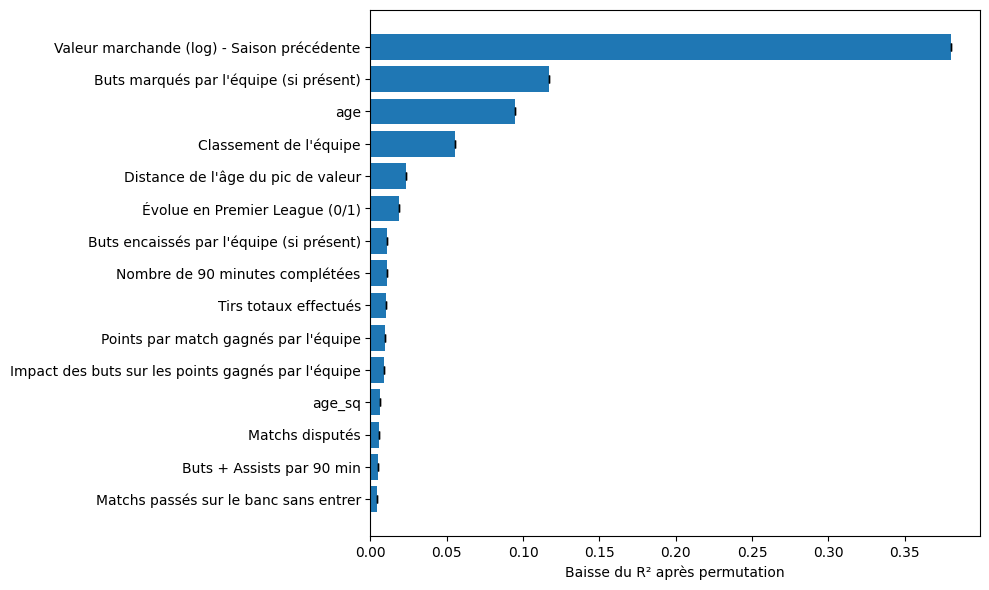

In [21]:
# Extraction des 15 variables les plus importantes
top15_importances = perm_importances.head(15).copy()

# 2. Mappage des noms de variables vers les libellés clairs
# On extrait la première valeur du tuple (le nom lisible) du DICT_VARIABLES
mapping_noms = {k: v[0] for k, v in DICT_VARIABLES.items()}

top15_importances["Feature_Label"] = top15_importances["Feature"].map(
    mapping_noms
)
# Secours : si une variable n'est pas dans le dictionnaire, on garde son nom brut
top15_importances["Feature_Label"] = top15_importances["Feature_Label"].fillna(
    top15_importances["Feature"]
)

# 3. Création du graphique avec l'ordre inverse [::-1] pour la disposition verticale
plt.figure(figsize=(10, 6))

plt.barh(
    top15_importances["Feature_Label"][::-1],
    top15_importances["Importance_Mean"][::-1],
    xerr=top15_importances["Importance_Std"][::-1],
    capsize=3,
)

plt.xlabel("Baisse du R² après permutation")
plt.tight_layout()
plt.show()

In [22]:
# print("Permutation Feature Importance par poste")

# # Liste des postes présents dans le jeu de validation
# postes = df_val["position"].dropna().unique().tolist()

# # Nombre minimum d'observations pour qu'un poste soit analysé (évite les postes anecdotiques)
# N_MIN_OBS = 30

# resultats_perm_par_poste = {}

# for poste in sorted(postes):
#     # Masque des lignes correspondant à ce poste (index aligné entre df_val, X_val, y_val)
#     mask = df_val["position"] == poste

#     if mask.sum() < N_MIN_OBS:
#         print(f"Poste '{poste}' ignoré ({mask.sum()} obs. < {N_MIN_OBS})")
#         continue

#     X_val_poste = X_val[mask.values]
#     y_val_poste = y_val[mask.values]

#     result_perm_poste = permutation_importance(
#         modele_stack,
#         X_val_poste,
#         y_val_poste,
#         scoring="neg_mean_absolute_percentage_error",
#         n_repeats=1,
#         random_state=1308,
#         n_jobs=-1
#     )

#     sorted_idx = result_perm_poste.importances_mean.argsort()[::-1]

#     perm_importances_poste = pd.DataFrame(
#         {
#             "Feature": X_val_poste.columns[sorted_idx],
#             "Importance_Mean": -result_perm_poste.importances_mean[sorted_idx],
#             "Importance_Std": result_perm_poste.importances_std[sorted_idx]
#         }
#     )

#     resultats_perm_par_poste[poste] = perm_importances_poste

#     print(f"\nPoste : {poste} (n={mask.sum()})")
#     print(perm_importances_poste.head(10))


# n_postes = len(resultats_perm_par_poste)
# fig, axes = plt.subplots(1, n_postes, figsize=(6 * n_postes, 6), sharex=False)

# if n_postes == 1:
#     axes = [axes]

# for ax, (poste, df_imp) in zip(axes, resultats_perm_par_poste.items()):
#     top = df_imp.head(10).iloc[::-1]
#     ax.barh(top["Feature"], top["Importance_Mean"], xerr=top["Importance_Std"], color="steelblue")
#     ax.set_title(f"Poste : {poste}")
#     ax.set_xlabel("Augmentation du MAPE après permutation")

# plt.tight_layout()
# plt.show()



Shap du stacking final


Background dataset has 2431 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2431 when initializing the masker.


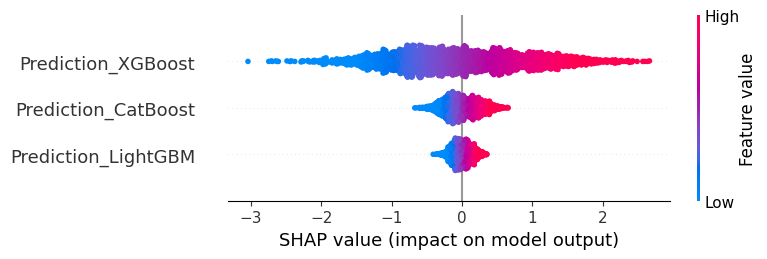

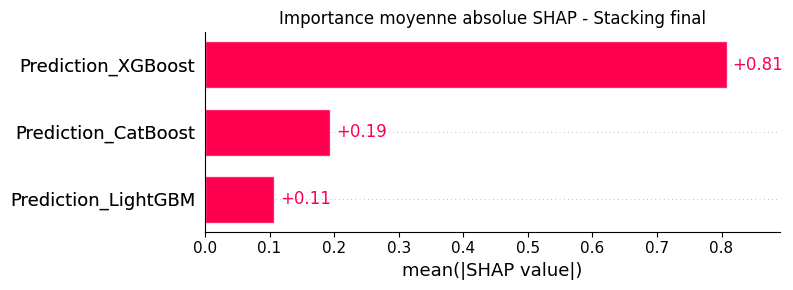


Explication locale de la première prédiction du jeu de validation


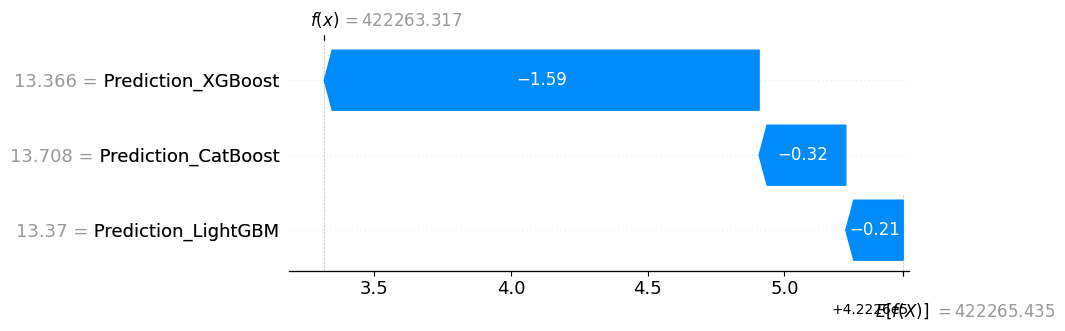

In [23]:
print("\nShap du stacking final")


# Le méta-modèle travaille sur les prédictions des modèles de base
X_meta_val = np.column_stack(
    [
        modeles_finaux["XGBoost (log)"].predict(X_val),
        modeles_finaux["LightGBM (log)"].predict(X_val),
        modeles_finaux["CatBoost (log)"].predict(X_val)
    ]
)


# Noms des variables du stacking
X_meta_val = pd.DataFrame(
    X_meta_val,
    columns=[
        "Prediction_XGBoost",
        "Prediction_LightGBM",
        "Prediction_CatBoost"
    ]
)


# Explainer adapté à LinearRegression
explainer = shap.LinearExplainer(
    meta,
    X_meta_val
)


shap_values = explainer(X_meta_val)



plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False
)



plt.tight_layout()
plt.show()





plt.figure(figsize=(10,6))

shap.plots.bar(
    shap_values,
    max_display=10,
    show=False
)

plt.title(
    "Importance moyenne absolue SHAP - Stacking final"
)

plt.tight_layout()
plt.show()





print(
    "\nExplication locale de la première prédiction du jeu de validation"
)


shap.plots.waterfall(
    shap_values[0],
    max_display=10
)

In [24]:
def regrouper_shap(shap_values, groupes):
    """
    groupes : dict {"Nom affiché": ["col1", "col2", ...]}
    Additionne les valeurs SHAP des colonnes de chaque groupe en une seule variable.
    """
    feature_names = list(shap_values.feature_names)
    values = shap_values.values.copy()
    data = shap_values.data.copy()

    colonnes_groupees = [c for cols in groupes.values() for c in cols]
    colonnes_gardees = [c for c in feature_names if c not in colonnes_groupees]
    idx_gardees = [feature_names.index(c) for c in colonnes_gardees]

    nouvelles_values = values[:, idx_gardees]
    nouvelles_data   = data[:, idx_gardees]
    nouveaux_noms    = colonnes_gardees.copy()

    for nom_groupe, cols in groupes.items():
        idx_cols = [feature_names.index(c) for c in cols if c in feature_names]
        somme_values = values[:, idx_cols].sum(axis=1, keepdims=True)
        # On garde la valeur brute de la 1ère colonne du groupe pour l'affichage (ex: age brut)
        donnee_repr = data[:, idx_cols[0]:idx_cols[0]+1]

        nouvelles_values = np.hstack([nouvelles_values, somme_values])
        nouvelles_data   = np.hstack([nouvelles_data, donnee_repr])
        nouveaux_noms.append(nom_groupe)

    return shap.Explanation(
        values=nouvelles_values,
        base_values=shap_values.base_values,
        data=nouvelles_data,
        feature_names=nouveaux_noms
    )

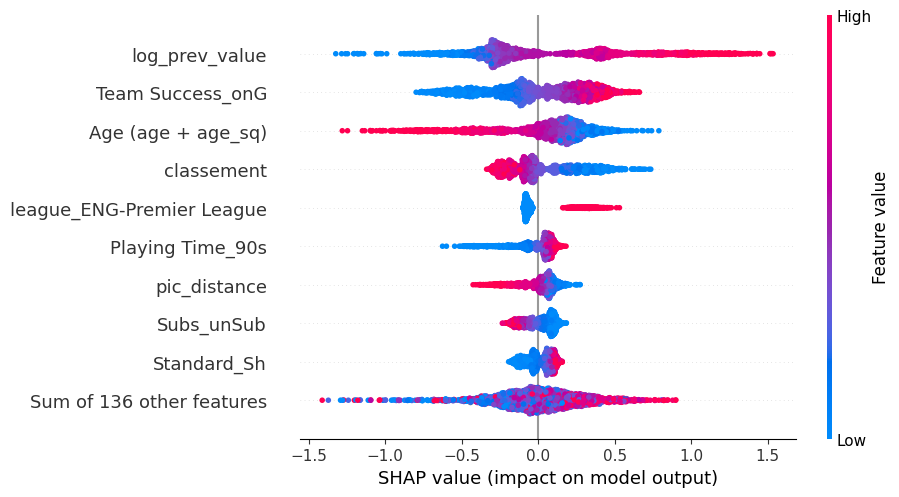

In [25]:
# Exemple sur XGBoost uniquement
explainer_xgb = shap.TreeExplainer(modeles_finaux["XGBoost (log)"])

shap_values_xgb = explainer_xgb(X_val)

groupes = {"Age (age + age_sq)": ["age", "age_sq"]}

shap_values_xgb_grouped = regrouper_shap(shap_values_xgb, groupes)

shap.plots.beeswarm(shap_values_xgb_grouped)

refaire le même avec barres et sous-cas (exemple donné par Thibault)

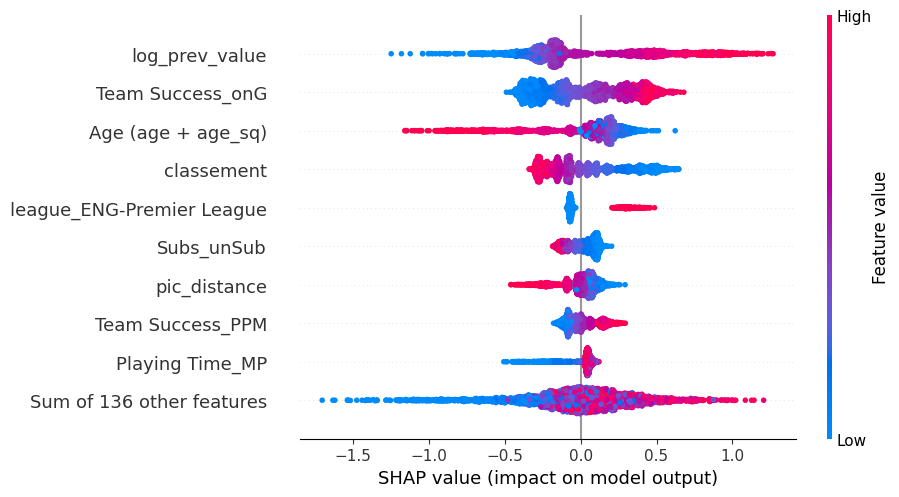

In [26]:
# Exemple sur CatBoost uniquement
explainer_cb = shap.TreeExplainer(modeles_finaux["CatBoost (log)"])
shap_values_cb = explainer_cb(X_val)

shap_values_cb_grouped = regrouper_shap(shap_values_cb, groupes)

shap.plots.beeswarm(shap_values_cb_grouped)

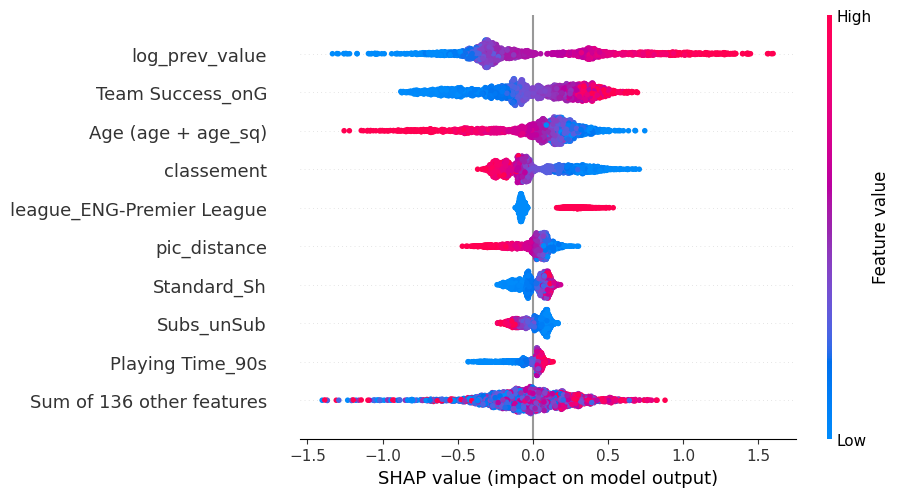

In [27]:
# Exemple sur LightGBM uniquement
explainer_lgb = shap.TreeExplainer(modeles_finaux["LightGBM (log)"])
shap_values_lgb = explainer_lgb(X_val)

shap_values_lgb_grouped = regrouper_shap(shap_values_lgb, groupes)

shap.plots.beeswarm(shap_values_lgb_grouped)

In [28]:


def renommer_features_shap(shap_values, dict_variables=DICT_VARIABLES, palette=PALETTE_PRO):
    """Remplace les feature_names techniques par les noms métier,
    et retourne {nom_affiché: couleur_famille} pour colorer les labels ensuite."""
    noms_originaux = list(shap_values.feature_names)

    noms_affiches = []
    couleur_par_label = {}
    for nom in noms_originaux:
        description, famille = dict_variables.get(nom, (nom, "Non Classifié"))
        noms_affiches.append(description)
        couleur_par_label[description] = palette.get(famille, "#2e3440")

    shap_values.feature_names = noms_affiches
    return couleur_par_label


def colorer_labels_waterfall(fig_ou_ax, couleur_par_label, couleur_defaut="#2e3440"):
    """Colore les labels du waterfall SHAP selon la famille de la variable.
    Ne modifie QUE la couleur (jamais le fontweight), car SHAP superpose deux
    couches de texte parfaitement alignées (valeur grise + nom noir) et changer
    la graisse de la police désaligne les deux couches (effet de texte dédoublé)."""
    fig = fig_ou_ax.figure if hasattr(fig_ou_ax, "figure") else fig_ou_ax
    ax = fig.axes[0]  # le premier axe contient les 2 couches de texte réellement visibles
    for label in ax.get_yticklabels():
        texte = label.get_text().strip()
        if texte in couleur_par_label:
            label.set_color(couleur_par_label[texte])

PermutationExplainer explainer: 2it [00:11, 11.05s/it]               


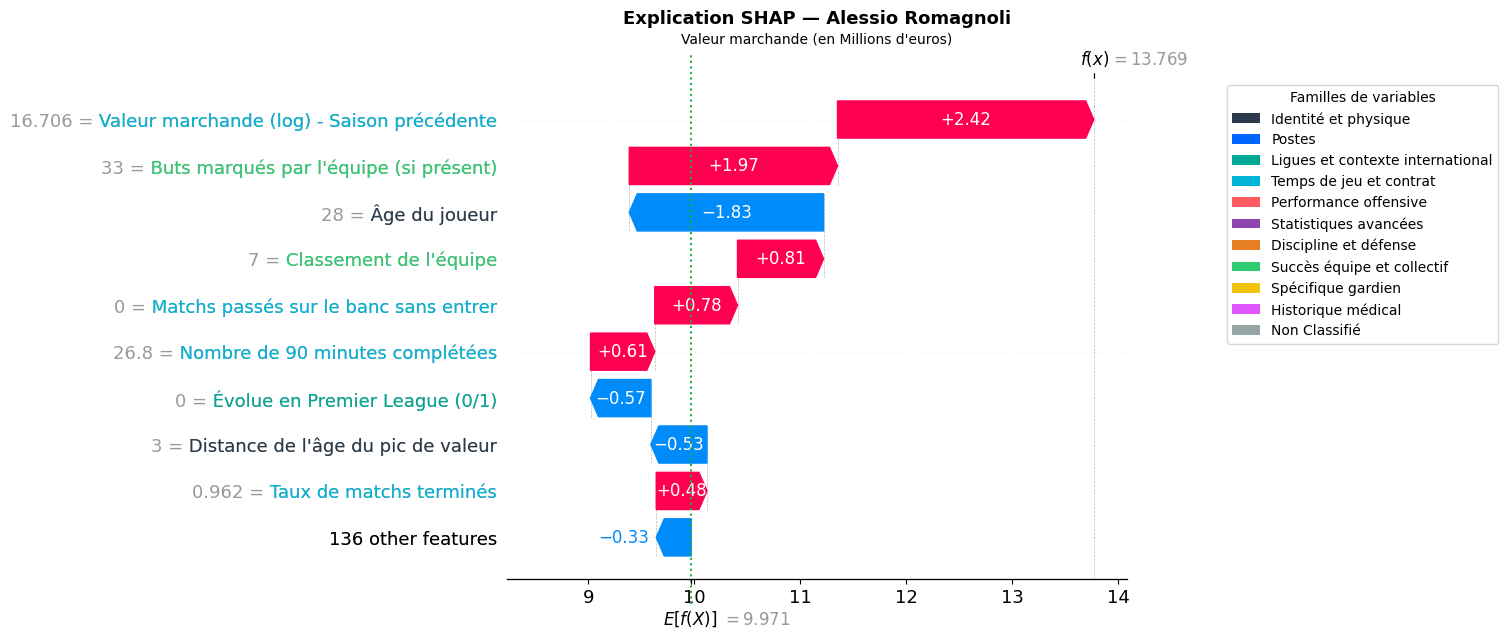

In [29]:
from matplotlib.patches import Patch

# Définition du modèle et des données
model_xgb = modeles_finaux["XGBoost (log)"]
indice_joueur = 90

nom_joueur = df_val[colonne_joueur].iloc[indice_joueur]

def predict_m_euro(X):
    return np.exp(model_xgb.predict(X)) / 1_000_000

background_data = shap.sample(X_val, 100)
explainer_m_euro = shap.Explainer(predict_m_euro, background_data)
shap_values_m_euro = explainer_m_euro(X_val.iloc[[indice_joueur]])

shap_values_m_euro_grouped = regrouper_shap(shap_values_m_euro, groupes)

shap_joueur = shap_values_m_euro_grouped[0]
couleur_par_label = renommer_features_shap(shap_joueur)

# Affichage du waterfall SHAP
plt.figure(figsize=(14, 6))
shap.plots.waterfall(shap_joueur, show=False)

fig = plt.gcf()
ax_reel = fig.axes[0]

colorer_labels_waterfall(fig, couleur_par_label)

# --- Remplacer la ligne E[f(X)] par des pointillés ---
e_fx = float(shap_joueur.base_values if np.isscalar(shap_joueur.base_values) else shap_joueur.base_values[0])

# Tolérance relative à l'échelle de l'axe (plus fiable qu'une valeur absolue fixe)
x_min, x_max = ax_reel.get_xlim()
tolerance = 0.01 * abs(x_max - x_min)  # 1% de la largeur du graphe

# On supprime TOUTES les lignes proches de E[f(X)], sur TOUS les axes de la figure
# (SHAP peut dessiner plusieurs segments à cette position : petite marque + trait)
for ax in fig.axes:
    for line in list(ax.lines):
        xdata = line.get_xdata()
        if len(xdata) >= 2 and np.isclose(xdata[0], xdata[-1]) and abs(xdata[0] - e_fx) < tolerance:
            line.remove()

# On trace notre unique ligne pointillée, sans clipping pour être sûr qu'elle couvre tout
ax_reel.axvline(
    x=e_fx, color="#23ad41", linestyle=":", linewidth=1.5,
    zorder=10, clip_on=False, ymin=-0.05, ymax=1.05,
)


# Légende des familles
familles_utilisees = {c: f for f, c in PALETTE_PRO.items() if c in couleur_par_label.values()}
legend_elements = [Patch(facecolor=c, label=f) for c, f in familles_utilisees.items()]
if legend_elements:
    ax_reel.legend(
        handles=legend_elements,
        title="Familles de variables",
        bbox_to_anchor=(1.15, 1),
        loc="upper left",
        frameon=True
    )

plt.title(f"Explication SHAP — {nom_joueur}", fontsize=13, fontweight="bold")
plt.xlabel("Valeur marchande (en Millions d'euros)")
plt.tight_layout()
plt.show()

In [30]:
fig = plt.gcf()
e_fx_calcule = float(shap_joueur.base_values if np.isscalar(shap_joueur.base_values) else shap_joueur.base_values[0])
print("e_fx calculé :", e_fx_calcule)

print("\nLignes verticales trouvées dans la figure :")
for i, ax in enumerate(fig.axes):
    for line in ax.lines:
        xdata = line.get_xdata()
        if len(xdata) >= 2 and np.isclose(xdata[0], xdata[-1]):
            print(f"  axe {i} -> x = {xdata[0]:.6f}  (écart avec e_fx: {abs(xdata[0]-e_fx_calcule):.6f})")

e_fx calculé : 9.97072447270155

Lignes verticales trouvées dans la figure :


<Figure size 640x480 with 0 Axes>

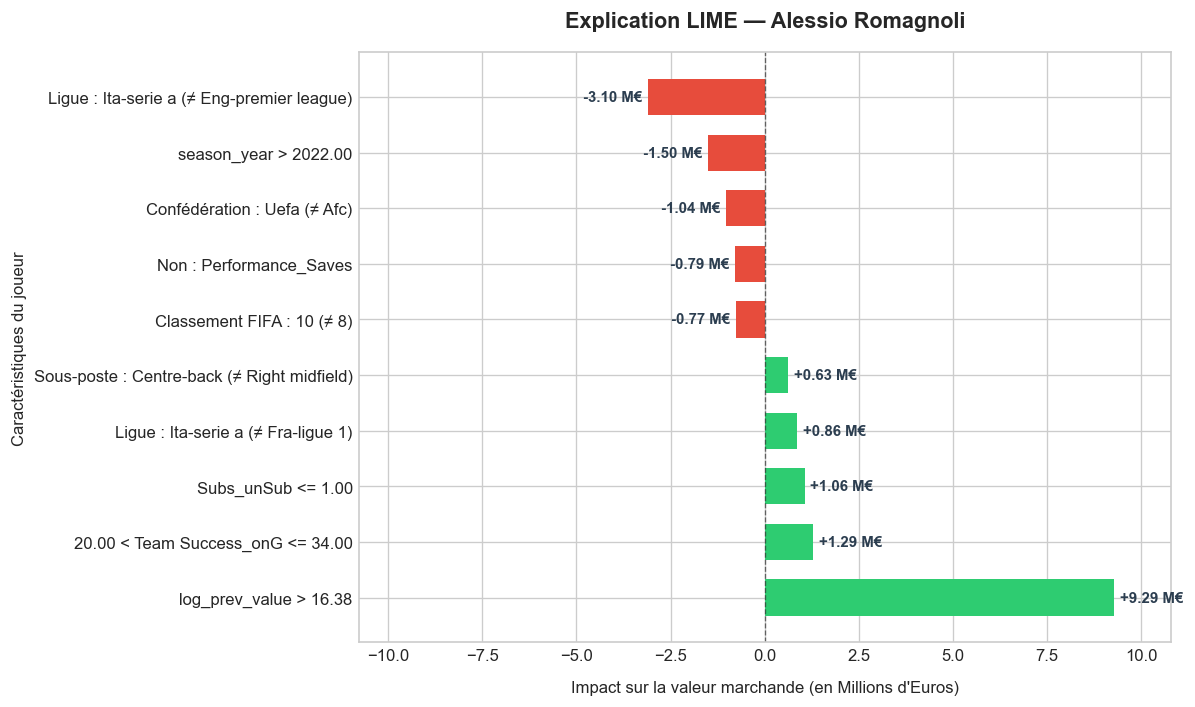

In [31]:
indice_joueur = 90

nom_joueur = df_val[colonne_joueur].iloc[indice_joueur]

model = modeles_finaux["XGBoost (log)"]

# Imputation des NaN pour LIME
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)

# Fonction de prédiction en Millions d'Euros
def predict_m_euro(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train.columns)
    log_preds = model.predict(X)
    return np.exp(log_preds) / 1_000_000

# Création de l'explicateur LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_imputed),
    feature_names=list(X_train.columns),
    class_names=['Valeur_M_Euro'],
    mode='regression',
    random_state=1308,
    feature_selection='highest_weights'
)

# Extraction des données du joueur choisi
joueur_data = X_test_imputed.iloc[indice_joueur].values

# Calcul de l'explication LIME
exp = explainer.explain_instance(
    data_row=joueur_data,
    predict_fn=predict_m_euro,
    num_features=10,
)



# Extraction des données
list_exp = exp.as_list()
df_lime = pd.DataFrame(list_exp, columns=['Feature_Condition', 'Impact'])
df_lime = df_lime.sort_values(by='Impact', ascending=False)

# Nettoyage des étiquettes
def clean_feature_label(condition):
    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "")
        return f"Non : {feat}"
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "")
        return f"Oui : {feat}"
    return condition

df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(clean_feature_label)
df_lime['Color'] = df_lime['Impact'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')

# Dictionnaire des familles de variables encodées en "one-hot" (dummies)
# clé = préfixe technique de la colonne, valeur = nom affiché de la famille
FAMILLES_ONE_HOT = {
    "confederation_": "Confédération",
    "league_": "Ligue",
    "pos_": "Poste",
    "sub_position_": "Sous-poste",
    "foot_": "Pied fort",
    "classement_FIFA" : "Classement FIFA",
    # ajoute ici tout autre préfixe de dummy présent dans ton dataset
}


def trouver_famille_one_hot(nom_colonne, familles=FAMILLES_ONE_HOT):
    """Retourne (prefixe, nom_famille) si la colonne appartient à une famille one-hot connue, sinon None."""
    for prefixe, nom_famille in familles.items():
        if nom_colonne.startswith(prefixe):
            return prefixe, nom_famille
    return None


def valeur_reelle_categorie(joueur_row, prefixe):
    """Cherche, parmi les colonnes de ce préfixe, celle qui vaut 1 pour ce joueur,
    et retourne son nom nettoyé (ex: 'confederation_europe' -> 'Europe')."""
    colonnes_famille = [c for c in joueur_row.index if c.startswith(prefixe)]
    for col in colonnes_famille:
        if joueur_row[col] == 1:
            return col[len(prefixe):].replace("_", " ").strip().capitalize()
    return "Inconnu"


def clean_feature_label(condition, joueur_row):
    """Nettoie le libellé LIME. Pour les variables one-hot, affiche la VRAIE
    catégorie du joueur plutôt qu'un simple Oui/Non peu explicite."""

    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "").strip()
        est_positif = False
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "").strip()
        est_positif = True
    else:
        return condition  # variable numérique continue : on laisse tel quel

    famille = trouver_famille_one_hot(feat)

    if famille is not None:
        prefixe, nom_famille = famille
        valeur_reelle = valeur_reelle_categorie(joueur_row, prefixe)
        categorie_testee = feat[len(prefixe):].replace("_", " ").strip().capitalize()

        if est_positif:
            # La condition testée est vraie -> c'est bien sa catégorie
            return f"{nom_famille} : {valeur_reelle}"
        else:
            # La condition testée est fausse -> on affiche sa VRAIE catégorie
            return f"{nom_famille} : {valeur_reelle} (≠ {categorie_testee})"

    # Cas générique : variable binaire simple qui n'est pas dans FAMILLES_ONE_HOT
    return f"Non : {feat}" if not est_positif else f"Oui : {feat}"


df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(
    lambda cond: clean_feature_label(cond, X_test_imputed.iloc[indice_joueur])
)

# Création de la figure
plt.figure(figsize=(10, 6), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

bars = plt.barh(
    y=df_lime['Pretty_Label'], 
    width=df_lime['Impact'], 
    color=df_lime['Color'],
    edgecolor='none',
    height=0.65
)

plt.axvline(x=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7)

# Textes au bout des barres
for bar in bars:
    width = bar.get_width()
    x_pos = width + (0.15 if width > 0 else -0.15)
    ha = 'left' if width > 0 else 'right'
    
    plt.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2, 
        f"{width:+.2f} M€", 
        va='center', 
        ha=ha, 
        fontsize=9, 
        fontweight='bold',
        color='#2c3e50'
    )

# Titre et axes
plt.title(f"Explication LIME — {nom_joueur}", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Impact sur la valeur marchande (en Millions d'Euros)", fontsize=10, labelpad=10)
plt.ylabel("Caractéristiques du joueur", fontsize=10)

x_max = max(abs(df_lime['Impact'].min()), abs(df_lime['Impact'].max())) + 1.5
plt.xlim(-x_max, x_max)

plt.tight_layout()
plt.show()

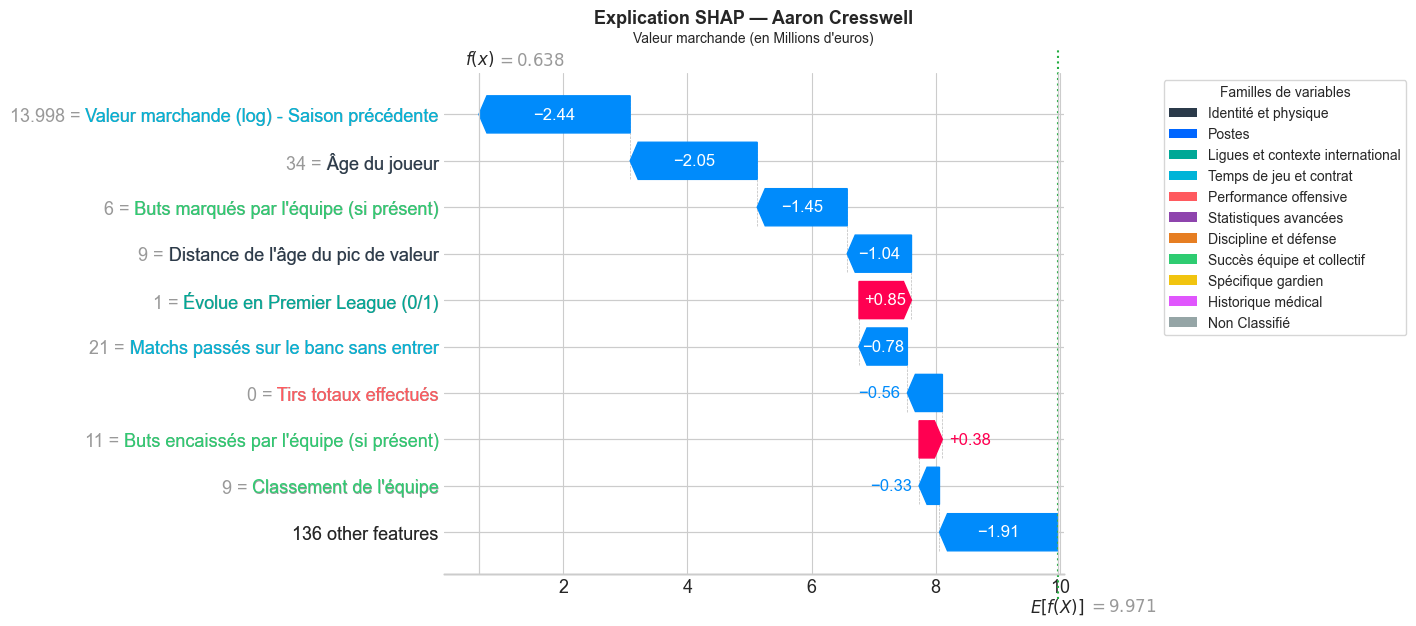

In [32]:
# Définition du modèle et des données
model_xgb = modeles_finaux["XGBoost (log)"]
indice_joueur = 0

nom_joueur = df_val[colonne_joueur].iloc[indice_joueur]

def predict_m_euro(X):
    return np.exp(model_xgb.predict(X)) / 1_000_000

background_data = shap.sample(X_val, 100)
explainer_m_euro = shap.Explainer(predict_m_euro, background_data)
shap_values_m_euro = explainer_m_euro(X_val.iloc[[indice_joueur]])

shap_values_m_euro_grouped = regrouper_shap(shap_values_m_euro, groupes)

shap_joueur = shap_values_m_euro_grouped[0]
couleur_par_label = renommer_features_shap(shap_joueur)

# Affichage du waterfall SHAP
plt.figure(figsize=(14, 6))
shap.plots.waterfall(shap_joueur, show=False)

fig = plt.gcf()
ax_reel = fig.axes[0]

colorer_labels_waterfall(fig, couleur_par_label)

# --- Remplacer la ligne E[f(X)] par des pointillés ---
e_fx = float(shap_joueur.base_values if np.isscalar(shap_joueur.base_values) else shap_joueur.base_values[0])

# Tolérance relative à l'échelle de l'axe (plus fiable qu'une valeur absolue fixe)
x_min, x_max = ax_reel.get_xlim()
tolerance = 0.01 * abs(x_max - x_min)  # 1% de la largeur du graphe

# On supprime TOUTES les lignes proches de E[f(X)], sur TOUS les axes de la figure
# (SHAP peut dessiner plusieurs segments à cette position : petite marque + trait)
for ax in fig.axes:
    for line in list(ax.lines):
        xdata = line.get_xdata()
        if len(xdata) >= 2 and np.isclose(xdata[0], xdata[-1]) and abs(xdata[0] - e_fx) < tolerance:
            line.remove()

# On trace notre unique ligne pointillée, sans clipping pour être sûr qu'elle couvre tout
ax_reel.axvline(
    x=e_fx, color="#23ad41", linestyle=":", linewidth=1.5,
    zorder=10, clip_on=False, ymin=-0.05, ymax=1.05,
)


# Légende des familles
familles_utilisees = {c: f for f, c in PALETTE_PRO.items() if c in couleur_par_label.values()}
legend_elements = [Patch(facecolor=c, label=f) for c, f in familles_utilisees.items()]
if legend_elements:
    ax_reel.legend(
        handles=legend_elements,
        title="Familles de variables",
        bbox_to_anchor=(1.15, 1),
        loc="upper left",
        frameon=True
    )

plt.title(f"Explication SHAP — {nom_joueur}", fontsize=13, fontweight="bold")
plt.xlabel("Valeur marchande (en Millions d'euros)")
plt.tight_layout()
plt.show()

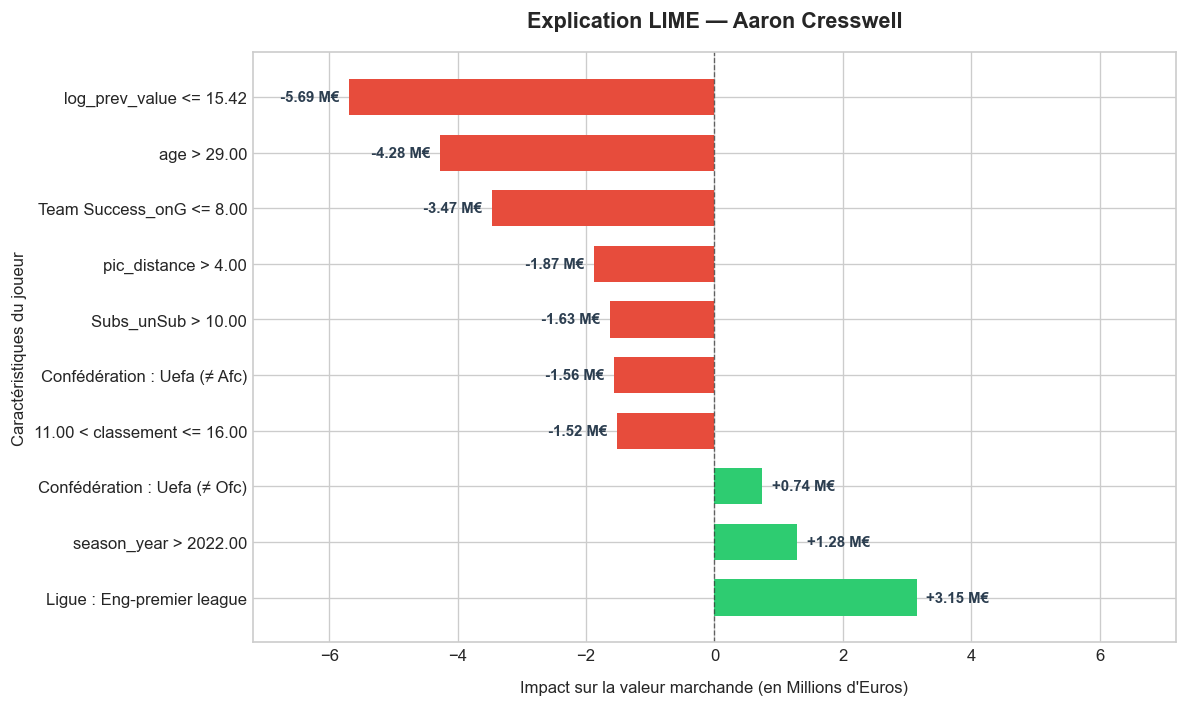

In [33]:
indice_joueur = 0

nom_joueur = df_test[colonne_joueur].iloc[indice_joueur]

model = modeles_finaux["XGBoost (log)"]

# Imputation des NaN pour LIME
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Fonction de prédiction en Millions d'Euros
def predict_m_euro(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=X_train.columns)
    log_preds = model.predict(X)
    return np.exp(log_preds) / 1_000_000

# Création de l'explicateur LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_imputed),
    feature_names=list(X_train.columns),
    class_names=['Valeur_M_Euro'],
    mode='regression',
    random_state=1308,
    feature_selection='highest_weights'
)

# Extraction des données du joueur choisi
joueur_data = X_test_imputed.iloc[indice_joueur].values

# Calcul de l'explication LIME
exp = explainer.explain_instance(
    data_row=joueur_data,
    predict_fn=predict_m_euro,
    num_features=10
)



# Extraction des données
list_exp = exp.as_list()
df_lime = pd.DataFrame(list_exp, columns=['Feature_Condition', 'Impact'])
df_lime = df_lime.sort_values(by='Impact', ascending=False)

# Nettoyage des étiquettes
def clean_feature_label(condition):
    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "")
        return f"Non : {feat}"
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "")
        return f"Oui : {feat}"
    return condition

df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(clean_feature_label)
df_lime['Color'] = df_lime['Impact'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')

# Dictionnaire des familles de variables encodées en "one-hot" (dummies)
# clé = préfixe technique de la colonne, valeur = nom affiché de la famille
FAMILLES_ONE_HOT = {
    "confederation_": "Confédération",
    "league_": "Ligue",
    "pos_": "Poste",
    "sub_position_": "Sous-poste",
    "foot_": "Pied fort",
    "classement_FIFA" : "Classement FIFA",
}


def trouver_famille_one_hot(nom_colonne, familles=FAMILLES_ONE_HOT):
    """Retourne (prefixe, nom_famille) si la colonne appartient à une famille one-hot connue, sinon None."""
    for prefixe, nom_famille in familles.items():
        if nom_colonne.startswith(prefixe):
            return prefixe, nom_famille
    return None


def valeur_reelle_categorie(joueur_row, prefixe):
    """Cherche, parmi les colonnes de ce préfixe, celle qui vaut 1 pour ce joueur,
    et retourne son nom nettoyé (ex: 'confederation_europe' -> 'Europe')."""
    colonnes_famille = [c for c in joueur_row.index if c.startswith(prefixe)]
    for col in colonnes_famille:
        if joueur_row[col] == 1:
            return col[len(prefixe):].replace("_", " ").strip().capitalize()
    return "Inconnu"


def clean_feature_label(condition, joueur_row):
    """Nettoie le libellé LIME. Pour les variables one-hot, affiche la VRAIE
    catégorie du joueur plutôt qu'un simple Oui/Non peu explicite."""

    if "<= 0.00" in condition:
        feat = condition.replace(" <= 0.00", "").strip()
        est_positif = False
    elif "> 0.00" in condition:
        feat = condition.replace(" > 0.00", "").strip()
        est_positif = True
    else:
        return condition  # variable numérique continue : on laisse tel quel

    famille = trouver_famille_one_hot(feat)

    if famille is not None:
        prefixe, nom_famille = famille
        valeur_reelle = valeur_reelle_categorie(joueur_row, prefixe)
        categorie_testee = feat[len(prefixe):].replace("_", " ").strip().capitalize()

        if est_positif:
            # La condition testée est vraie -> c'est bien sa catégorie
            return f"{nom_famille} : {valeur_reelle}"
        else:
            # La condition testée est fausse -> on affiche sa VRAIE catégorie
            return f"{nom_famille} : {valeur_reelle} (≠ {categorie_testee})"

    # Cas générique : variable binaire simple qui n'est pas dans FAMILLES_ONE_HOT
    return f"Non : {feat}" if not est_positif else f"Oui : {feat}"


df_lime['Pretty_Label'] = df_lime['Feature_Condition'].apply(
    lambda cond: clean_feature_label(cond, X_test_imputed.iloc[indice_joueur])
)

# Création de la figure
plt.figure(figsize=(10, 6), dpi=120)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

bars = plt.barh(
    y=df_lime['Pretty_Label'], 
    width=df_lime['Impact'], 
    color=df_lime['Color'],
    edgecolor='none',
    height=0.65
)

plt.axvline(x=0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7)

# Textes au bout des barres
for bar in bars:
    width = bar.get_width()
    x_pos = width + (0.15 if width > 0 else -0.15)
    ha = 'left' if width > 0 else 'right'
    
    plt.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2, 
        f"{width:+.2f} M€", 
        va='center', 
        ha=ha, 
        fontsize=9, 
        fontweight='bold',
        color='#2c3e50'
    )

# Titre et axes
plt.title(f"Explication LIME — {nom_joueur}", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("Impact sur la valeur marchande (en Millions d'Euros)", fontsize=10, labelpad=10)
plt.ylabel("Caractéristiques du joueur", fontsize=10)

x_max = max(abs(df_lime['Impact'].min()), abs(df_lime['Impact'].max())) + 1.5
plt.xlim(-x_max, x_max)

plt.tight_layout()
plt.show()

## C. Trajectoires de valeur marchande : groupes de joueurs similaires

Objectif : identifier des groupes de joueurs dont la valeur marchande évolue de façon similaire
d'une saison à l'autre, quantifier ces variations (€ et %), puis expliquer (SHAP local puis global)
ce qui caractérise chaque groupe. Le but final est un support de storytelling permettant de conseiller
un club selon sa stratégie : **plus-value** (dénicher un profil qui va prendre de la valeur) ou
**performance immédiate** (recruter un profil déjà performant, quitte à payer plus cher).

Comme le split train/val/test/en_cours est **temporel**, un même joueur peut apparaître dans plusieurs
de ces jeux selon l'année. On reconstitue donc d'abord un historique complet par joueur, toutes saisons
confondues, avant de calculer les trajectoires et de faire du clustering.

### C.1 : Reconstitution de l'historique complet par joueur (toutes saisons, tous splits)

In [126]:
# Reconstitution de l'historique complet par joueur, toutes saisons confondues
# (les splits train/val/test/en_cours sont temporels : un même joueur peut apparaître
# dans plusieurs d'entre eux selon les années)

colonnes_historique = [colonne_joueur, colonne_team, "season_year", colonne_cible, "pic_distance"]

df_train_hist    = df_train[colonnes_historique].copy();    df_train_hist["split"]    = "train"
df_val_hist      = df_val[colonnes_historique].copy();      df_val_hist["split"]      = "val"
df_test_hist     = df_test[colonnes_historique].copy();     df_test_hist["split"]     = "test"
df_en_cours_hist = df_en_cours[colonnes_historique].copy(); df_en_cours_hist["split"] = "en_cours"

df_historique = pd.concat(
    [df_train_hist, df_val_hist, df_test_hist, df_en_cours_hist],
    ignore_index=True
).sort_values([colonne_joueur, "season_year"])

# Sécurité : un joueur ne doit avoir qu'une seule ligne par saison
df_historique = df_historique.drop_duplicates(subset=[colonne_joueur, "season_year"]).reset_index(drop=True)

print(f"{df_historique[colonne_joueur].nunique()} joueurs uniques sur {df_historique['season_year'].nunique()} saisons.")
df_historique.head(10)

4720 joueurs uniques sur 6 saisons.


,player,team,season_year,market_value_in_eur,pic_distance,split
0,Aaron Anselmino,Strasbourg,2025,12000000.0,-5,en_cours
1,Aaron Connolly,Brighton,2020,7000000.0,-5,train
2,Aaron Cresswell,West Ham United,2020,5000000.0,6,train
3,Aaron Cresswell,West Ham United,2021,3000000.0,7,train
4,Aaron Cresswell,West Ham United,2022,1200000.0,8,train
5,Aaron Cresswell,West Ham United,2023,900000.0,9,val
6,Aaron Cresswell,West Ham United,2024,700000.0,10,test
7,Aaron Hickey,Bologna,2020,5000000.0,-7,train
8,Aaron Hickey,Bologna,2021,18000000.0,-6,train
9,Aaron Hickey,Brentford,2022,25000000.0,-5,train


### C.2 : Écarts de valeur marchande d'une saison à l'autre (€ et %)

In [127]:
# Calcul des écarts de valeur marchande d'une saison à l'autre, pour chaque joueur
# (VMnew - VMinitiale) et (VMnew - VMinitiale) / VMinitiale

df_historique["VM_precedente"]      = df_historique.groupby(colonne_joueur)[colonne_cible].shift(1)
df_historique["saison_precedente"]  = df_historique.groupby(colonne_joueur)["season_year"].shift(1)

df_historique["delta_vm_eur"] = df_historique[colonne_cible] - df_historique["VM_precedente"]
df_historique["delta_vm_pct"] = (
    (df_historique[colonne_cible] - df_historique["VM_precedente"]) / df_historique["VM_precedente"]
)

# On ne garde le delta que si les deux saisons sont réellement consécutives (écart de 1 an)
ecart_saisons = df_historique["season_year"] - df_historique["saison_precedente"]
mask_non_consecutif = ecart_saisons != 1
df_historique.loc[mask_non_consecutif, ["delta_vm_eur", "delta_vm_pct"]] = np.nan

df_historique[[colonne_joueur, "season_year", colonne_cible, "delta_vm_eur", "delta_vm_pct"]].head(15)

,player,season_year,market_value_in_eur,delta_vm_eur,delta_vm_pct
0,Aaron Anselmino,2025,12000000.0,NaN,NaN
1,Aaron Connolly,2020,7000000.0,NaN,NaN
2,Aaron Cresswell,2020,5000000.0,NaN,NaN
3,Aaron Cresswell,2021,3000000.0,-2000000.0,-0.400000
4,Aaron Cresswell,2022,1200000.0,-1800000.0,-0.600000
5,Aaron Cresswell,2023,900000.0,-300000.0,-0.250000
6,Aaron Cresswell,2024,700000.0,-200000.0,-0.222222
7,Aaron Hickey,2020,5000000.0,NaN,NaN
8,Aaron Hickey,2021,18000000.0,13000000.0,2.600000
9,Aaron Hickey,2022,25000000.0,7000000.0,0.388889


### C.3 : Constitution des groupes de joueurs à trajectoires similaires (clustering)

In [128]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler

# PARAMÈTRES ET PRÉPARATION DES DONNÉES

colonne_joueur = "player"
N_MIN_VARIATIONS = 3  # Nb minimum de saisons renseignées pour garder le joueur
N_CLUSTERS = 4  # <-- paramètre à faire varier
PERCENTILE_CLIP = (
    0.01  # winsorisation à 1% / 99% pour neutraliser les outliers extrêmes
)

# Construction de la table pivot (Joueur x Saison = Variation en €)
pivot_abs = df_historique.pivot_table(
    index=colonne_joueur, columns="season_year", values="delta_vm_eur"
)

joueurs_retenus = pivot_abs.dropna(thresh=N_MIN_VARIATIONS).index
pivot_abs_complet = pivot_abs.loc[joueurs_retenus].copy()

print(
    f"Nombre de joueurs retenus pour la classification : {len(pivot_abs_complet)} "
    f"(sur {len(pivot_abs)} au total).\n"
)

# CALCUL DES INDICATEURS DE TRAJECTOIRE

stats_joueurs = pd.DataFrame(index=pivot_abs_complet.index)
stats_joueurs["mean_delta_eur"] = pivot_abs_complet.mean(axis=1)
stats_joueurs["std_delta_eur"] = pivot_abs_complet.std(axis=1).fillna(0)
stats_joueurs["nb_seasons"] = pivot_abs_complet.notna().sum(axis=1)

# Récupération de la dernière saison connue par joueur (VM, pic_distance et postes binaires)
colonnes_a_recuperer = [colonne_cible, "pic_distance"]

dernières_infos = (
    df_historique.dropna(subset=[colonne_cible])
    .sort_values("season_year")
    .groupby(colonne_joueur)[colonnes_a_recuperer]
    .last()
)

stats_joueurs["market_value_in_eur"] = dernières_infos[colonne_cible]
stats_joueurs["pic_distance"] = dernières_infos["pic_distance"]


stats_joueurs = stats_joueurs.dropna(
    subset=["market_value_in_eur", "pic_distance"]
)

# TRAITEMENT DES OUTLIERS ET DES ÉCHELLES AVANT CLUSTERING

stats_joueurs["log_market_value"] = np.log1p(
    stats_joueurs["market_value_in_eur"]
)

for col in ["mean_delta_eur", "std_delta_eur"]:
    borne_basse = stats_joueurs[col].quantile(PERCENTILE_CLIP)
    borne_haute = stats_joueurs[col].quantile(1 - PERCENTILE_CLIP)
    stats_joueurs[col + "_clip"] = stats_joueurs[col].clip(
        borne_basse, borne_haute
    )

# CLUSTERING K-MEANS

features_cluster = (
    ["mean_delta_eur_clip", "std_delta_eur_clip", "log_market_value", "pic_distance"]
)

scaler = RobustScaler()
X_cluster = scaler.fit_transform(stats_joueurs[features_cluster])

# Aide au choix de N_CLUSTERS : silhouette score pour k = 2 à 8
scores = {}
for k in range(2, 9):
    km_test = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_test = km_test.fit_predict(X_cluster)
    scores[k] = silhouette_score(X_cluster, labels_test)

print("Silhouette score par nombre de clusters :")
for k, s in scores.items():
    marqueur = "  <-- N_CLUSTERS actuel" if k == N_CLUSTERS else ""
    print(f"  k={k} : {s:.3f}{marqueur}")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
stats_joueurs["cluster"] = kmeans.fit_predict(X_cluster)
stats_joueurs["profil_metier"] = (
    "Cluster " + stats_joueurs["cluster"].astype(str)
)

print("\nRÉPARTITION DES JOUEURS PAR CLUSTER")
effectifs = stats_joueurs["profil_metier"].value_counts().sort_index()
pourcentages = (
    stats_joueurs["profil_metier"].value_counts(normalize=True).sort_index()
    * 100
)
df_synthese = pd.DataFrame(
    {"Effectif": effectifs, "Proportion (%)": pourcentages.round(1)}
)
print(df_synthese)

print(
    "\nSTATISTIQUES DES TRAJECTOIRES PAR CLUSTER (valeurs non-clippées pour lecture)"
)
resume_groupes = stats_joueurs.groupby("profil_metier").agg(
    mean_delta_moyen=("mean_delta_eur", "mean"),
    std_delta_moyen=("std_delta_eur", "mean"),
    vm_moyenne=("market_value_in_eur", "mean"),
)
resume_groupes["mean_delta_moyen"] = (
    resume_groupes["mean_delta_moyen"].round(0).astype(str) + " €"
)
resume_groupes["std_delta_moyen"] = (
    resume_groupes["std_delta_moyen"].round(0).astype(str) + " €"
)
resume_groupes["vm_moyenne"] = resume_groupes["vm_moyenne"].round(0)
print(resume_groupes)

Nombre de joueurs retenus pour la classification : 1414 (sur 3042 au total).

Silhouette score par nombre de clusters :
  k=2 : 0.464
  k=3 : 0.378
  k=4 : 0.346  <-- N_CLUSTERS actuel
  k=5 : 0.319
  k=6 : 0.314
  k=7 : 0.316
  k=8 : 0.294

RÉPARTITION DES JOUEURS PAR CLUSTER
               Effectif  Proportion (%)
profil_metier                          
Cluster 0           694            49.1
Cluster 1           421            29.8
Cluster 2           203            14.4
Cluster 3            96             6.8

STATISTIQUES DES TRAJECTOIRES PAR CLUSTER (valeurs non-clippées pour lecture)
              mean_delta_moyen std_delta_moyen  vm_moyenne
profil_metier                                             
Cluster 0         -1144105.0 €     2000402.0 €   3857781.0
Cluster 1          1907454.0 €     6631575.0 €  21307601.0
Cluster 2         -6983703.0 €     7926030.0 €  14665517.0
Cluster 3         12062101.0 €    15940015.0 €  68302083.0


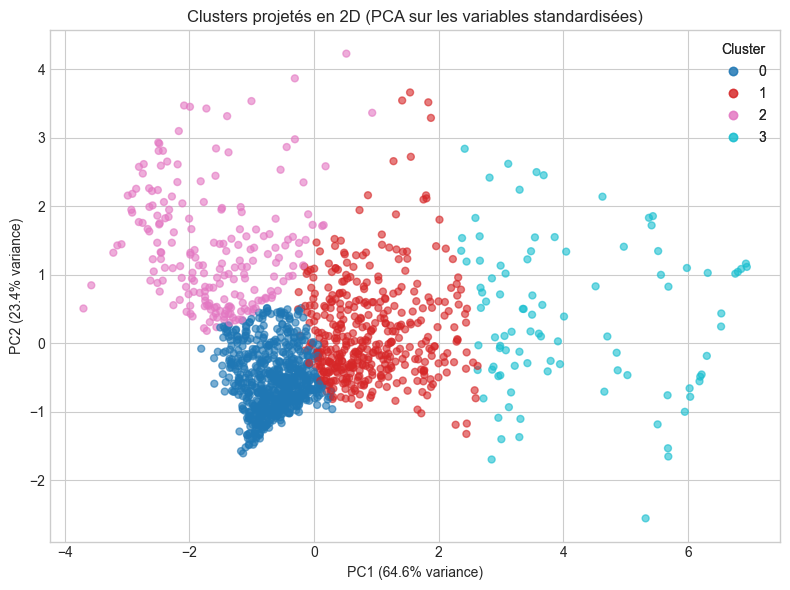

Variance totale expliquée par PC1+PC2 : 88.0%


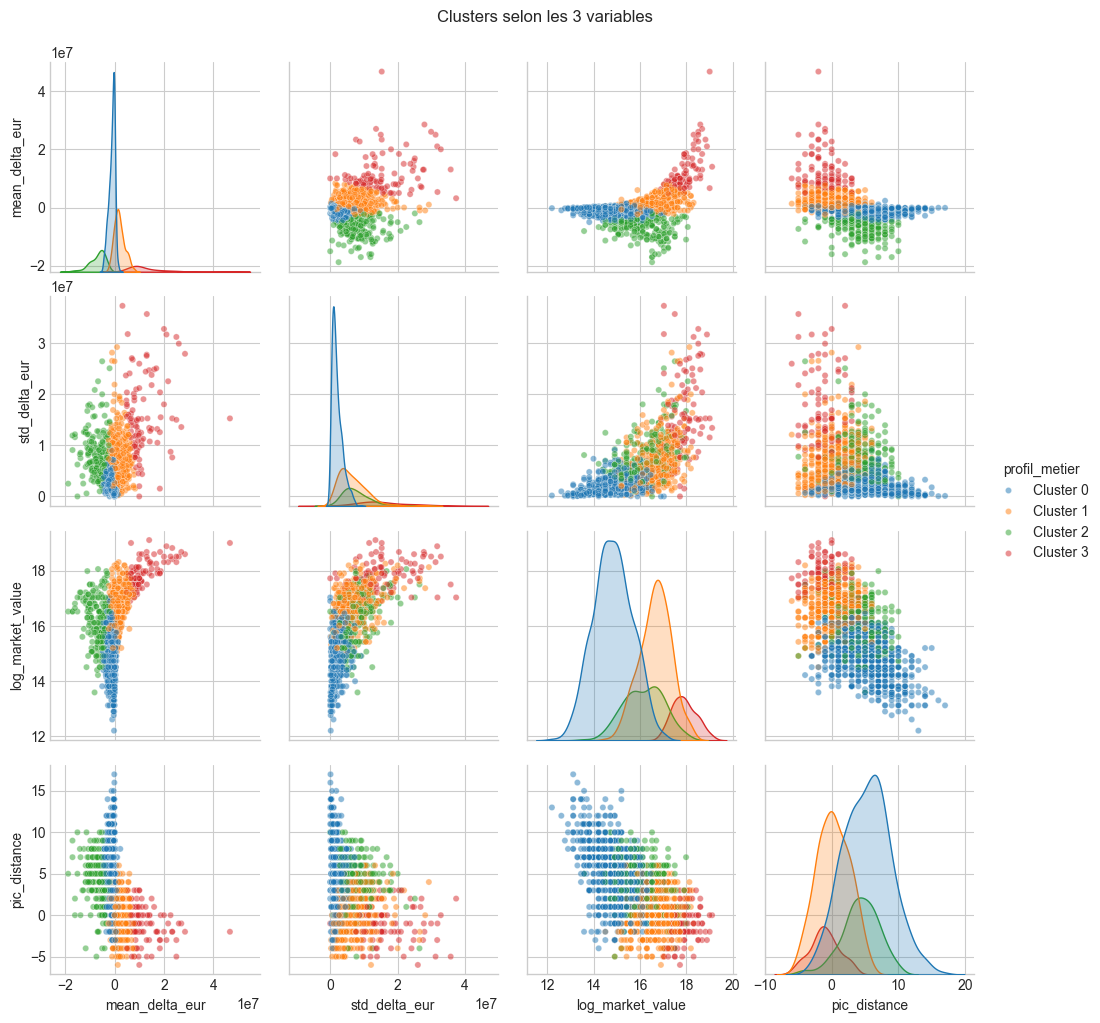

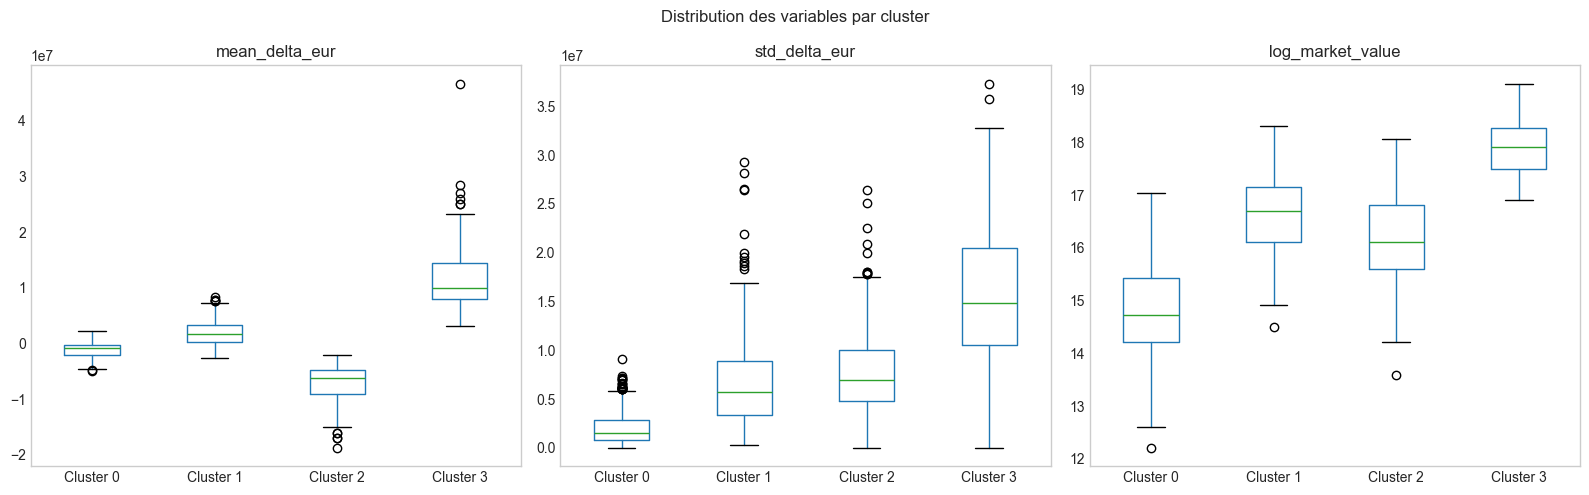

In [129]:
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Projection PCA 2D de l'espace utilisé pour le clustering (vue d'ensemble)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=stats_joueurs["cluster"], cmap="tab10", alpha=0.6, s=25
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Clusters projetés en 2D (PCA sur les variables standardisées)")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()
print(f"Variance totale expliquée par PC1+PC2 : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# 2. Nuages de points 2 à 2 sur les variables brutes (plus interprétable métier que la PCA)
features_plot = ["mean_delta_eur", "std_delta_eur", "log_market_value", "pic_distance"]
df_plot = stats_joueurs[features_plot + ["profil_metier"]].copy()

sns.pairplot(
    df_plot, hue="profil_metier", diag_kind="kde",
    palette="tab10", plot_kws={"alpha": 0.5, "s": 20}
)
plt.suptitle("Clusters selon les 3 variables", y=1.02)
plt.show()

# 3. Boxplots par variable : où se situe chaque cluster sur chaque axe
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, features_plot):
    stats_joueurs.boxplot(column=col, by="profil_metier", ax=ax, grid=False)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Distribution des variables par cluster")
plt.tight_layout()
plt.show()

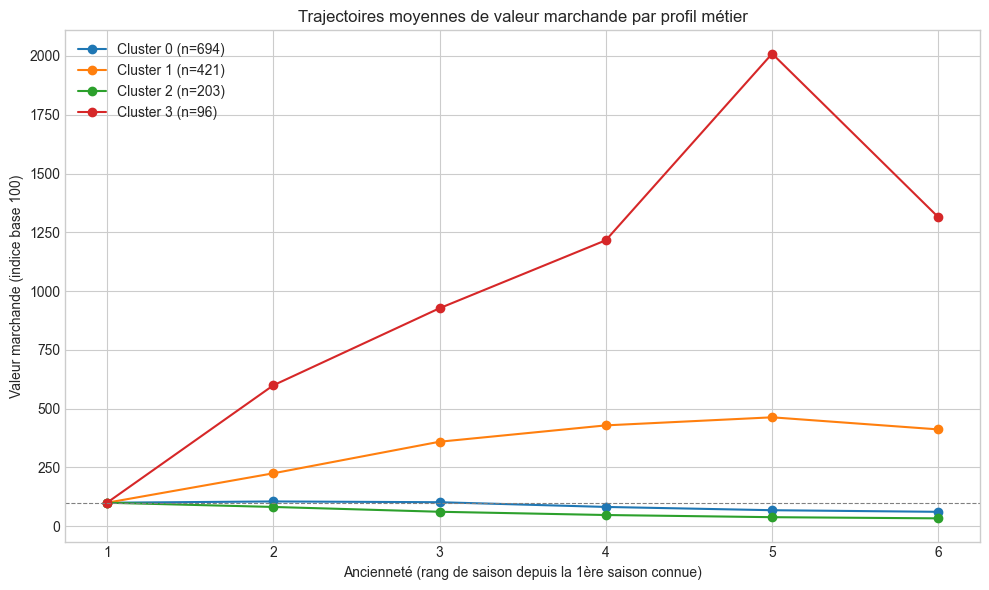

In [130]:
# Trajectoire moyenne de VM (indice base 100 à la première saison connue) par profil


df_clusters = stats_joueurs.reset_index()[[colonne_joueur, "profil_metier"]]

df_traj_full = df_historique.merge(df_clusters, on=colonne_joueur, how="inner")

df_traj_full = df_traj_full.sort_values(by=[colonne_joueur, "season_year"])
df_traj_full["vm_premiere_saison"] = df_traj_full.groupby(colonne_joueur)[colonne_cible].transform("first")
df_traj_full["indice_vm"] = (df_traj_full[colonne_cible] / df_traj_full["vm_premiere_saison"]) * 100

# Rang de saison (1ère, 2ème, ...) pour aligner des joueurs qui n'ont pas commencé la même année
df_traj_full["rang_saison"] = df_traj_full.groupby(colonne_joueur)["season_year"].rank(method="first").astype(int)

trajectoires_moyennes = df_traj_full.groupby(["profil_metier", "rang_saison"])["indice_vm"].mean().unstack(level=0)

# Ne conserver que les points (profil, rang_saison) qui ont au moins 5 joueurs
counts_grid = df_traj_full.groupby(["rang_saison", "profil_metier"]).size().unstack()
trajectoires_filtrees = trajectoires_moyennes.copy()
trajectoires_filtrees[counts_grid < 30] = None

# Masquer les saisons où l'effectif devient trop faible
for col in trajectoires_filtrees.columns:
    saisons_valides = counts_grid[col][counts_grid[col] >= 30].index
    trajectoires_filtrees.loc[
        ~trajectoires_filtrees.index.isin(saisons_valides), col
    ] = None

plt.figure(figsize=(10, 6))
for profil in trajectoires_filtrees.columns:
    effectif = (df_clusters["profil_metier"] == profil).sum()
    plt.plot(
        trajectoires_filtrees.index,
        trajectoires_filtrees[profil],
        marker="o",
        label=f"{profil} (n={effectif})"
    )

plt.axhline(100, color="grey", linestyle="--", linewidth=0.8)
plt.xlabel("Ancienneté (rang de saison depuis la 1ère saison connue)")
plt.ylabel("Valeur marchande (indice base 100)")
plt.title("Trajectoires moyennes de valeur marchande par profil métier")
plt.legend()
plt.tight_layout()
plt.show()

### C.4 : Explicabilité locale — un même joueur, année après année (SHAP)

On choisit un joueur représentatif d'un groupe (variable `GROUPE_ETUDIE` / `JOUEUR_ETUDIE` ci-dessous,
à ajuster après avoir regardé le graphique précédent et choisi le groupe qui vous intéresse), et on
affiche le waterfall SHAP pour **chaque saison où il est présent dans le dataset**, quel que soit le
split d'origine (train/val/test/en_cours).

In [131]:
# Fonction utilitaire : retrouver la ligne de features (X) d'un joueur pour une saison donnée,
# quel que soit le split où elle se trouve (les index de X_* sont alignés sur ceux de df_*)

DATASETS_PAR_SPLIT = {
    "train":    (df_train, X_train),
    "val":      (df_val, X_val),
    "test":     (df_test, X_test),
    "en_cours": (df_en_cours, X_en_cours),
}

def recuperer_ligne_joueur(nom_joueur, annee):
    for split, (df_split, X_split) in DATASETS_PAR_SPLIT.items():
        mask = (df_split[colonne_joueur] == nom_joueur) & (df_split["season_year"] == annee)
        if mask.any():
            idx = df_split[mask].index[0]
            return X_split.loc[[idx]], split
    return None, None


# Fonction de prédiction du stacking final, directement en Millions d'euros
def predict_m_euro_stack(X):
    return modele_stack.predict(X) / 1_000_000

# Background pour l'explainer model-agnostic (échantillon de X_train)
background_data_stack = shap.sample(X_train, 100, random_state=RANDOM_STATE)
explainer_stack = shap.Explainer(predict_m_euro_stack, background_data_stack)

Étude du joueur : Adri Embarba (profil « Cluster 0 ») — saisons disponibles : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


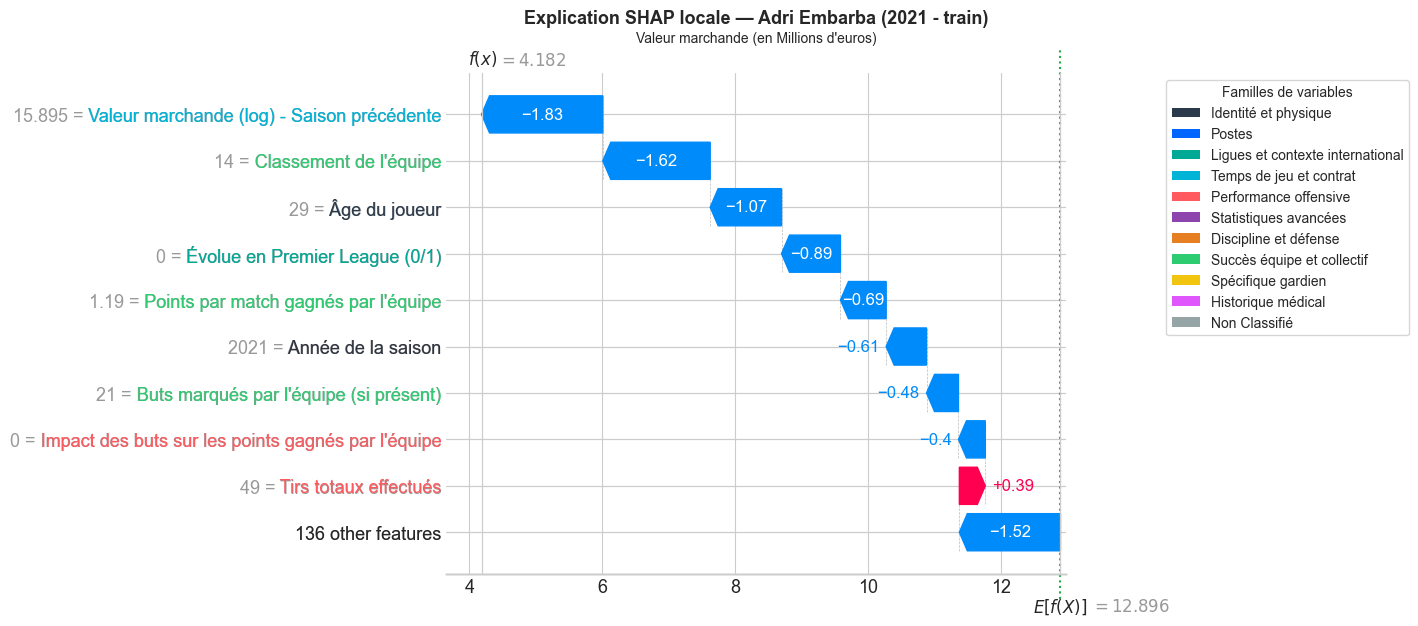

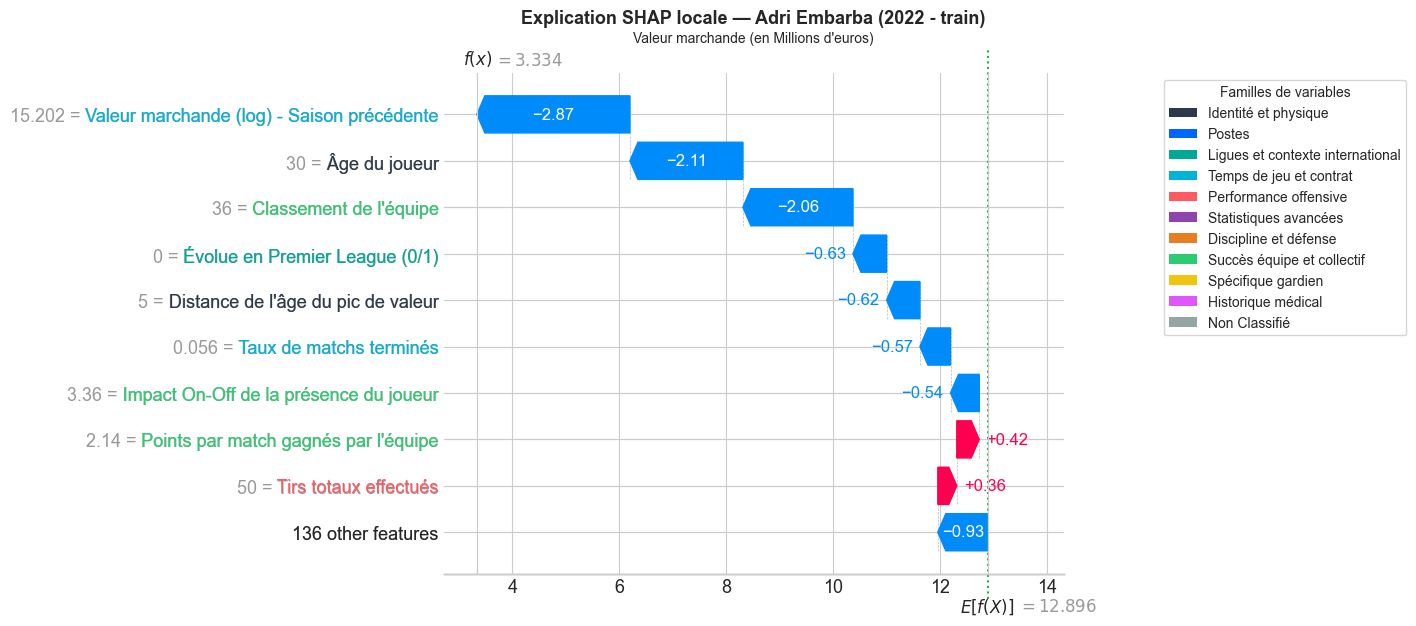

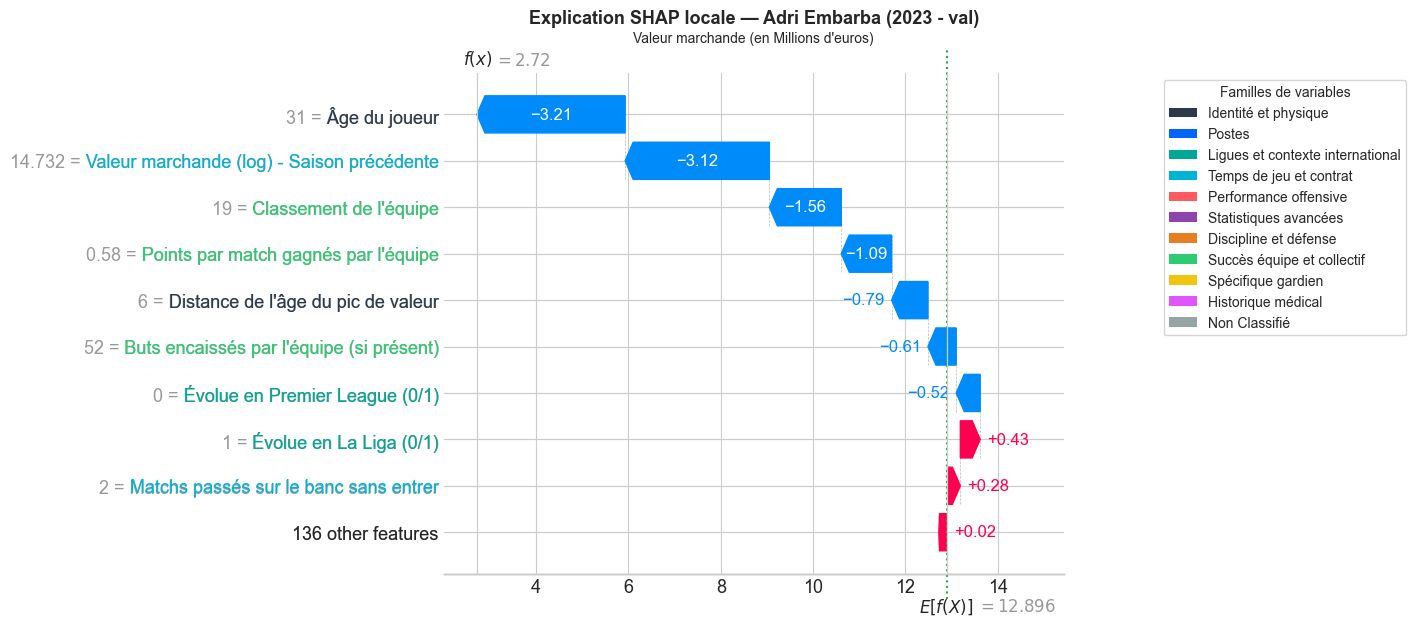

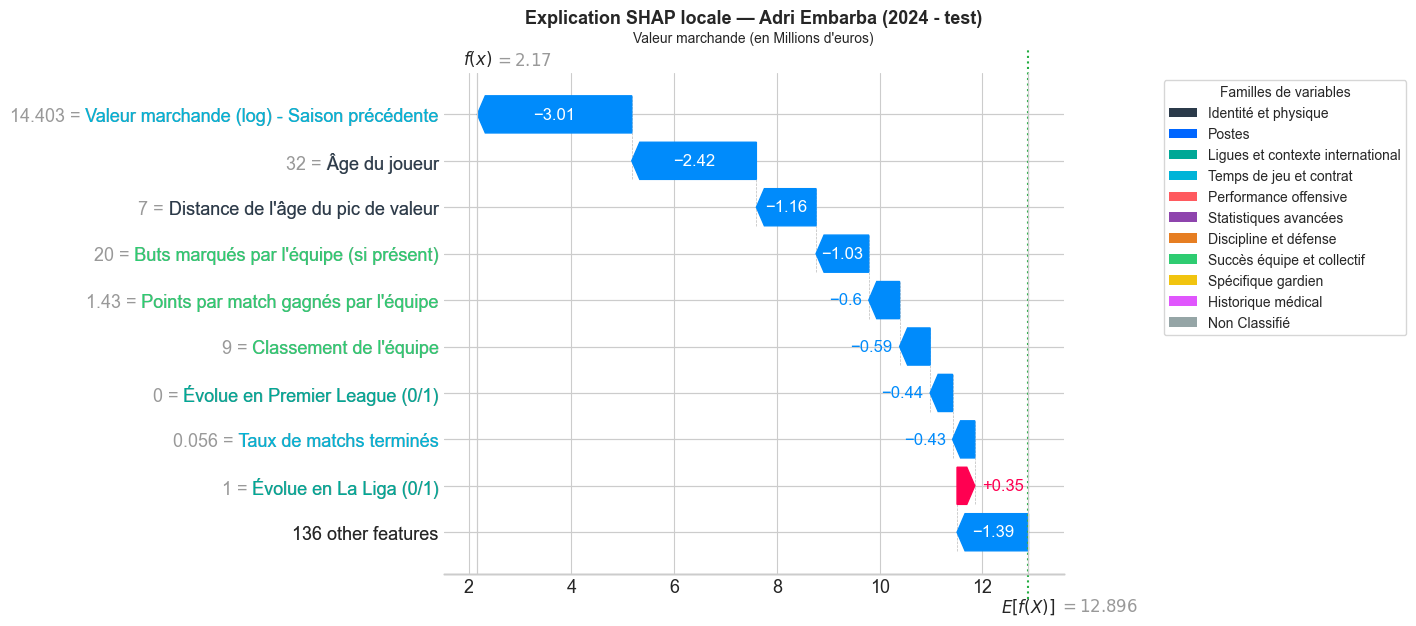

In [132]:
# À ajuster : le profil et le joueur que l'on souhaite étudier en détail
GROUPE_ETUDIE = "Cluster 0"
JOUEUR_ETUDIE = df_clusters.loc[df_clusters["profil_metier"] == GROUPE_ETUDIE, colonne_joueur].iloc[11]

annees_joueur = sorted(df_historique.loc[df_historique[colonne_joueur] == JOUEUR_ETUDIE, "season_year"].unique())
print(f"Étude du joueur : {JOUEUR_ETUDIE} (profil « {GROUPE_ETUDIE} ») — saisons disponibles : {annees_joueur}")

for annee in annees_joueur:
    X_joueur_annee, split_trouve = recuperer_ligne_joueur(JOUEUR_ETUDIE, annee)
    if X_joueur_annee is None:
        continue

    shap_values_annee = explainer_stack(X_joueur_annee)
    shap_values_annee_grouped = regrouper_shap(shap_values_annee, groupes)
    shap_joueur_annee = shap_values_annee_grouped[0]
    couleur_par_label = renommer_features_shap(shap_joueur_annee)

    plt.figure(figsize=(24, 6))
    shap.plots.waterfall(shap_joueur_annee, show=False)
    
    fig = plt.gcf()
    ax_reel = fig.axes[0]

    # Application de la coloration sur les labels
    colorer_labels_waterfall(fig, couleur_par_label)

    # --- Remplacer la ligne E[f(X)] par des pointillés ---
    e_fx = float(shap_joueur_annee.base_values if np.isscalar(shap_joueur_annee.base_values) else shap_joueur_annee.base_values[0])

    # Tolérance relative à l'échelle de l'axe
    x_min, x_max = ax_reel.get_xlim()
    tolerance = 0.01 * abs(x_max - x_min)

    # Suppression des lignes d'origine de SHAP proches de E[f(X)]
    for ax in fig.axes:
        for line in list(ax.lines):
            xdata = line.get_xdata()
            if len(xdata) >= 2 and np.isclose(xdata[0], xdata[-1]) and abs(xdata[0] - e_fx) < tolerance:
                line.remove()

    # Ajout de la ligne en pointillés custom
    ax_reel.axvline(
        x=e_fx, color="#23ad41", linestyle=":", linewidth=1.5,
        zorder=10, clip_on=False, ymin=-0.05, ymax=1.05,
    )

    # --- Ajout de la Légende des Familles ---
    familles_utilisees = {c: f for f, c in PALETTE_PRO.items() if c in couleur_par_label.values()}
    legend_elements = [Patch(facecolor=c, label=f) for c, f in familles_utilisees.items()]
    if legend_elements:
        ax_reel.legend(
            handles=legend_elements,
            title="Familles de variables",
            bbox_to_anchor=(1.15, 1),
            loc="upper left",
            frameon=True
        )

    plt.title(f"Explication SHAP locale — {JOUEUR_ETUDIE} ({annee} - {split_trouve})", fontsize=13, fontweight="bold")
    plt.xlabel("Valeur marchande (en Millions d'euros)")
    # Au lieu de juste plt.tight_layout(), tu peux faire :
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Garde 15% d'espace à droite pour la légende
    plt.show()

### C.5 : Explicabilité globale du groupe (SHAP agrégé)

On agrège les explications SHAP sur l'ensemble des joueurs du groupe (une ligne = dernière saison
connue de chaque joueur du groupe) pour faire ressortir le **profil type** : quelles variables
expliquent, en moyenne, la valeur marchande de ce type de joueur.

694 joueurs inclus dans l'explicabilité globale du profil « Cluster 0 ».


PermutationExplainer explainer: 695it [38:32,  3.35s/it]                         


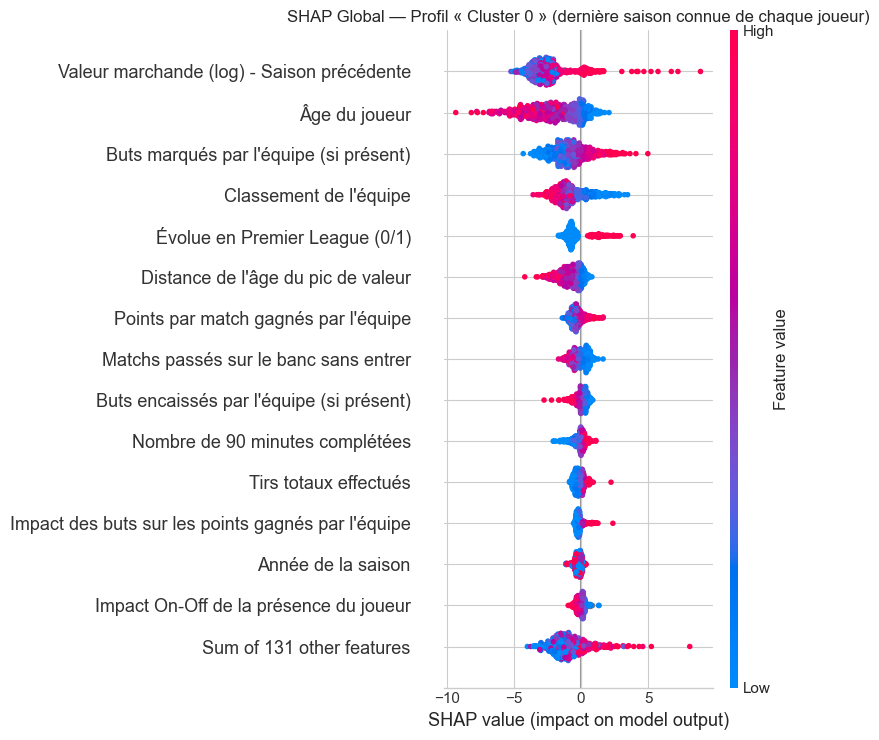

In [133]:
# Explicabilité GLOBALE du groupe : quelles variables expliquent le profil de ce type de joueur ?

joueurs_du_groupe = df_clusters.loc[df_clusters["profil_metier"] == GROUPE_ETUDIE, colonne_joueur].tolist()

# Pour chaque joueur du groupe, on récupère sa ligne la plus récente disponible
lignes_groupe = []
for joueur in joueurs_du_groupe:
    annees = sorted(df_historique.loc[df_historique[colonne_joueur] == joueur, "season_year"].unique())
    if not annees:
        continue
    X_ligne, _ = recuperer_ligne_joueur(joueur, annees[-1])
    if X_ligne is not None:
        lignes_groupe.append(X_ligne)

X_groupe = pd.concat(lignes_groupe)
print(f"{len(X_groupe)} joueurs inclus dans l'explicabilité globale du profil « {GROUPE_ETUDIE} ».")

shap_values_groupe = explainer_stack(X_groupe)
shap_values_groupe_grouped = regrouper_shap(shap_values_groupe, groupes)
couleur_par_label_groupe = renommer_features_shap(shap_values_groupe_grouped)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_values_groupe_grouped, max_display=15, show=False)
plt.title(f"SHAP Global — Profil « {GROUPE_ETUDIE} » (dernière saison connue de chaque joueur)")
plt.tight_layout()
plt.show()

421 joueurs inclus dans l'explicabilité globale du profil « Cluster 1 ».


PermutationExplainer explainer: 422it [24:21,  3.50s/it]                         


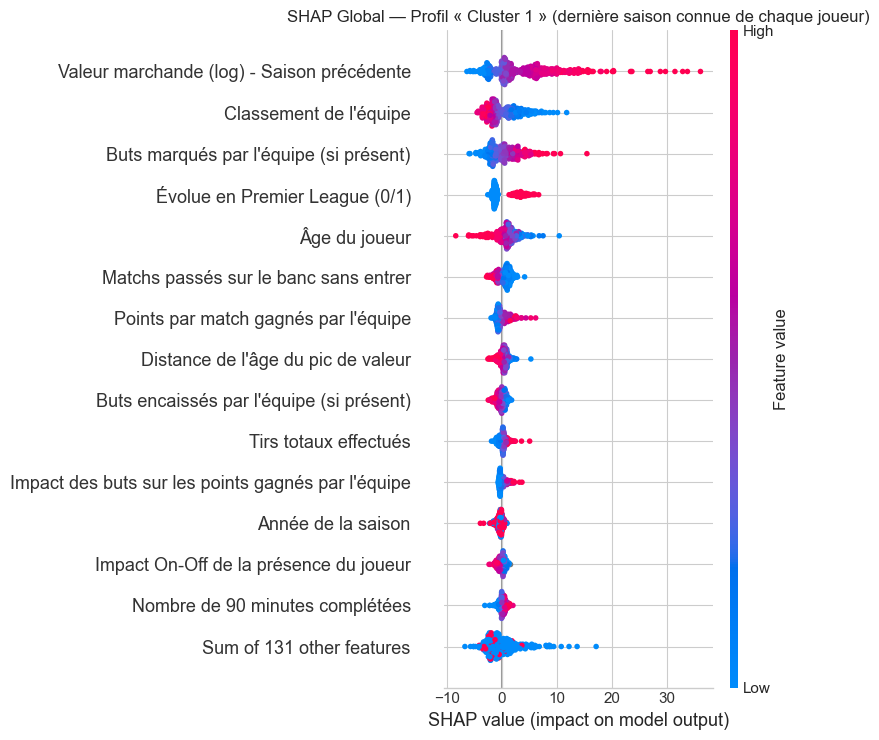

In [134]:
# Explicabilité GLOBALE du groupe : quelles variables expliquent le profil de ce type de joueur ?

joueurs_du_groupe = df_clusters.loc[df_clusters["profil_metier"] == "Cluster 1", colonne_joueur].tolist()

# Pour chaque joueur du groupe, on récupère sa ligne la plus récente disponible
lignes_groupe = []
for joueur in joueurs_du_groupe:
    annees = sorted(df_historique.loc[df_historique[colonne_joueur] == joueur, "season_year"].unique())
    if not annees:
        continue
    X_ligne, _ = recuperer_ligne_joueur(joueur, annees[-1])
    if X_ligne is not None:
        lignes_groupe.append(X_ligne)

X_groupe = pd.concat(lignes_groupe)
print(f"{len(X_groupe)} joueurs inclus dans l'explicabilité globale du profil « {"Cluster 1"} ».")

shap_values_groupe = explainer_stack(X_groupe)
shap_values_groupe_grouped = regrouper_shap(shap_values_groupe, groupes)
couleur_par_label_groupe = renommer_features_shap(shap_values_groupe_grouped)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_values_groupe_grouped, max_display=15, show=False)
plt.title(f"SHAP Global — Profil « {"Cluster 1"} » (dernière saison connue de chaque joueur)")
plt.tight_layout()
plt.show()

203 joueurs inclus dans l'explicabilité globale du profil « Cluster 2 ».


PermutationExplainer explainer: 204it [11:53,  3.57s/it]                         


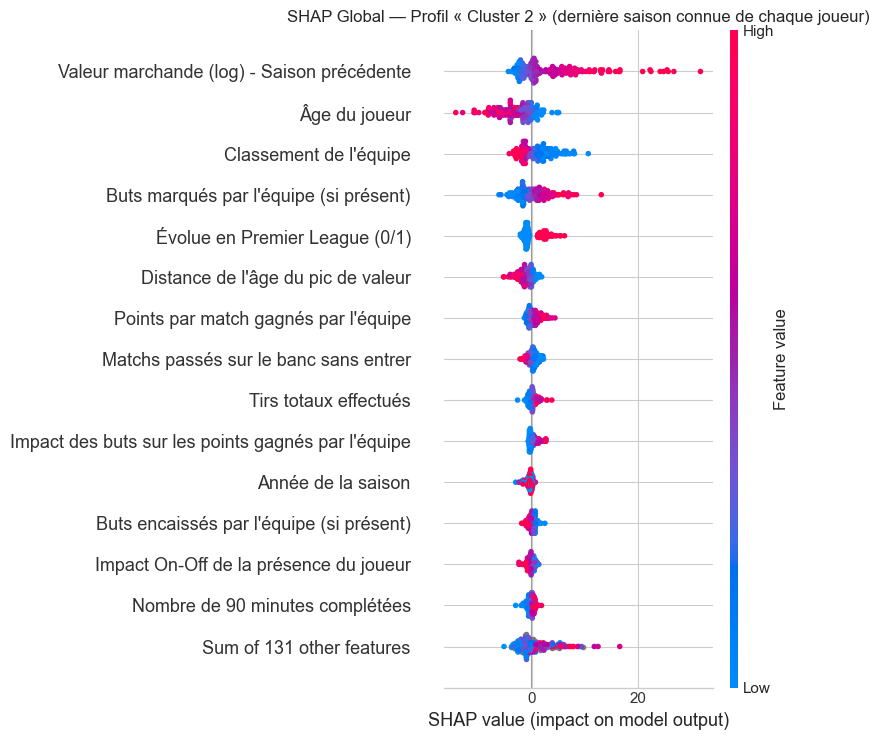

In [135]:
# Explicabilité GLOBALE du groupe : quelles variables expliquent le profil de ce type de joueur ?

joueurs_du_groupe = df_clusters.loc[df_clusters["profil_metier"] == "Cluster 2", colonne_joueur].tolist()

# Pour chaque joueur du groupe, on récupère sa ligne la plus récente disponible
lignes_groupe = []
for joueur in joueurs_du_groupe:
    annees = sorted(df_historique.loc[df_historique[colonne_joueur] == joueur, "season_year"].unique())
    if not annees:
        continue
    X_ligne, _ = recuperer_ligne_joueur(joueur, annees[-1])
    if X_ligne is not None:
        lignes_groupe.append(X_ligne)

X_groupe = pd.concat(lignes_groupe)
print(f"{len(X_groupe)} joueurs inclus dans l'explicabilité globale du profil « {"Cluster 2"} ».")

shap_values_groupe = explainer_stack(X_groupe)
shap_values_groupe_grouped = regrouper_shap(shap_values_groupe, groupes)
couleur_par_label_groupe = renommer_features_shap(shap_values_groupe_grouped)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_values_groupe_grouped, max_display=15, show=False)
plt.title(f"SHAP Global — Profil « {"Cluster 2"} » (dernière saison connue de chaque joueur)")
plt.tight_layout()
plt.show()

96 joueurs inclus dans l'explicabilité globale du profil « Cluster 3 ».


PermutationExplainer explainer: 97it [06:04,  3.92s/it]                        


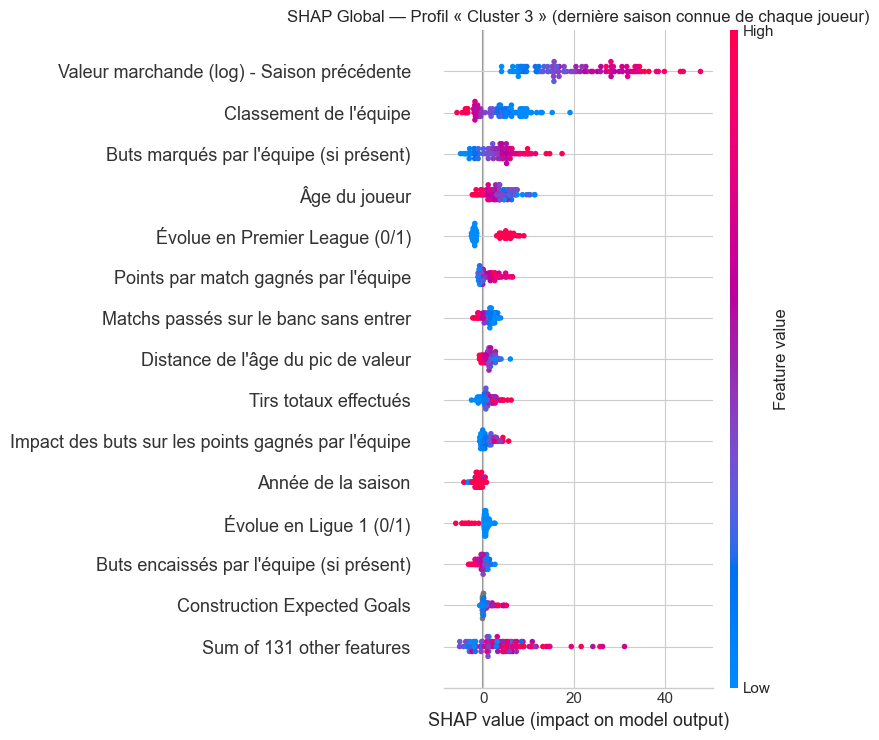

In [136]:
# Explicabilité GLOBALE du groupe : quelles variables expliquent le profil de ce type de joueur ?

joueurs_du_groupe = df_clusters.loc[df_clusters["profil_metier"] == "Cluster 3", colonne_joueur].tolist()

# Pour chaque joueur du groupe, on récupère sa ligne la plus récente disponible
lignes_groupe = []
for joueur in joueurs_du_groupe:
    annees = sorted(df_historique.loc[df_historique[colonne_joueur] == joueur, "season_year"].unique())
    if not annees:
        continue
    X_ligne, _ = recuperer_ligne_joueur(joueur, annees[-1])
    if X_ligne is not None:
        lignes_groupe.append(X_ligne)

X_groupe = pd.concat(lignes_groupe)
print(f"{len(X_groupe)} joueurs inclus dans l'explicabilité globale du profil « {"Cluster 3"} ».")

shap_values_groupe = explainer_stack(X_groupe)
shap_values_groupe_grouped = regrouper_shap(shap_values_groupe, groupes)
couleur_par_label_groupe = renommer_features_shap(shap_values_groupe_grouped)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_values_groupe_grouped, max_display=15, show=False)
plt.title(f"SHAP Global — Profil « {"Cluster 3"} » (dernière saison connue de chaque joueur)")
plt.tight_layout()
plt.show()

### C.6 : Storytelling & grille de lecture pour le recrutement

Comment lire les groupes obtenus pour conseiller un club selon sa stratégie :

- **Stratégie plus-value** : chercher un groupe dont la trajectoire moyenne (graphique C.3) montre une
  **croissance forte et régulière** sur les premières saisons, et dont le SHAP global (C.5) est tiré par
  des variables de potentiel plutôt que de performance déjà réalisée (âge/`pic_distance` faible,
  progression de temps de jeu, ligue en développement...). Le SHAP local année après année (C.4)
  permet de vérifier que la mécanique de valorisation est bien la même pour un joueur individuel du
  groupe, et pas un artefact de moyenne.
- **Stratégie performance immédiate** : chercher un groupe déjà stable ou en plateau haut, dont le SHAP
  global est tiré par des variables de performance pure sur la saison en cours (buts, xG, temps de jeu,
  contribution offensive/défensive), quitte à payer une VM déjà élevée.

Pensez à croiser ces groupes avec le **poste** (`position`) du joueur recherché : un même profil de
trajectoire n'a pas la même lecture chez un gardien que chez un attaquant.